# Статистическое исследование торговых сессий для стратегии мартингейла

**Цель.** Каждая сессия в `data/*.npz` построена вокруг резкого движения цены. Нужно понять, что происходит после этого движения:
как часто цена продолжает движение, как часто разворачивается, насколько резко и как долго это длится — и можно ли на этом строить мартингейл.
Исследование выполняется на всех сплитах, затем `train` сравнивается с `val`, `test`, `backtest`.

## 1. Откуда берутся сессии (важно для интерпретации)

Сессии созданы скриптом `signal_detection/signal_detection.py` (функция `get_signal_non_overlapping`) с параметрами из `signal_detection/config.py`:

| параметр | значение | роль |
|---|---|---|
| `volatility_high` | 10 мин | длина окна, в котором ищется резкое движение |
| `volatility_threshold` | 0.05 | порог: `abs(close[t+10]/close[t] − 1) ≥ 5%` |
| `volatility_low` | 90 мин | длина «фонового» периода до движения |
| `lambda_coef` | 5 | контраст: среднее по фону abs(10-минутное изменение) должно быть меньше `abs(change)/5` |
| `pre_signal` / `post_signal` | 90 / 60 мин | сколько минут до и после сигнальной свечи попадает в сессию |

Алгоритм: для каждой минуты `t` считается 10-минутное изменение цены закрытия; если оно ≥ 5% по модулю **и** в предшествующие ~80 минут среднее 10-минутное изменение было как минимум в 5 раз меньше, минута `t+10` объявляется **сигнальной**. В сессию попадают 89 минут до неё, она сама и 60 минут после — итого 150 строк. Внутри одного тикера сессии не пересекаются.

Следствия:
- по построению в **каждой** сессии на индексах 79→89 есть движение ≥ 5%, а до него — «тихий» рынок. Поэтому всё, что происходит до индекса 89, нельзя рассматривать как «случайную выборку рынка» — это результат отбора (см. [selection bias](https://en.wikipedia.org/wiki/Selection_bias)). Честные вопросы можно задавать только про пост-окно (индексы 90…149): детектор его не видел;
- исследование отвечает на **условный** вопрос: «что делает цена *при условии*, что только что было резкое движение на фоне затишья», а не «как ведёт себя цена вообще».

## 2. Данные и раскладка сессии

Файлы `train_data.npz`, `val_data.npz`, `test_data.npz`, `backtest_data.npz` — **хронологические** сплиты одного набора (train: 2020-01 → 2025-03, val: 2025-03 → 2025-04, test: 2025-04 → 2025-07, backtest: 2025-07 → 2025-09). Поэтому сравнение train с остальными — это проверка **устойчивости во времени** (смены рыночного режима), а не просто проверка на другой случайной выборке. `data.npz` — объединение четырёх сплитов, отдельно не загружается; агрегат `all` = конкатенация сплитов.

Каждая сессия — массив `(150, 7)`: 150 минут × каналы `open, high, low, close, volume, num_trades, volume_weighted_average` (минутные [OHLC-свечи](https://en.wikipedia.org/wiki/Open-high-low-close_chart); `volume_weighted_average` в этих данных = `(open + high + low + close) / 4`).

| индексы | что это |
|---|---|
| 0 … 79 | «спокойный» пресигнальный участок |
| 79 → 89 | сигнальное движение: за 10 минут `abs(close[89]/close[79] − 1) ≥ 5%` |
| 89 | сигнальная свеча; `P0 = close[89]` — точка отсчёта всех метрик |
| 90 … 149 | пост-окно, 60 минут; «минута `h` после сигнала» = индекс `89 + h` |

**Почему точка отсчёта — `close[89]`.** Это первая цена, по которой трейдер, увидевший сигнал, реально может открыть позицию: сигнал формируется на закрытии свечи 89 (детектор смотрит на `close[t+10]`). Все доходности и экскурсии считаются относительно `P0`, то есть описывают опыт позиции, открытой по цене `P0` в момент сигнала.

## 3. Определения и соглашение о знаке

- `dir = sign(close[89] − close[79])` — направление сигнала: `+1` рост (памп), `−1` падение (дамп).
- `M = abs(close[89]/close[79] − 1)` — размер сигнального движения (доля: 0.05 = 5%).
- **Подписанные метрики.** Чтобы объединять up- и down-сигналы, все относительные изменения цены умножаются на `dir`. Тогда положительное значение всегда означает «цена пошла дальше в сторону сигнала» (продолжение), отрицательное — «цена пошла назад» (разворот, откат). Пример: после дампа (`dir = −1`) цена упала ещё на 2% → `close/P0 − 1 = −0.02`, подписанное значение `(−1)·(−0.02) = +0.02` — продолжение.
- `r_h = dir·(close[89+h]/P0 − 1)` — подписанная доходность через `h` минут после сигнала (по ценам закрытия).
- `MFE` (maximum favorable excursion) — максимальная экскурсия в сторону продолжения по внутриминутным экстремумам (`high` для up, `low` для down); `MAE` (maximum adverse excursion) — максимальная экскурсия в сторону разворота. «Favorable / adverse» — с точки зрения позиции **по направлению сигнала**; для контртрендовой позиции всё зеркально: её прибыль — это `MAE`. Оба значения также приводятся в долях `M`.
- `t_peak`, `t_trough` — минуты, на которых достигнуты `MFE` и `MAE`; `t_rev_k`, `t_cont_k` — минута первого достижения разворота / продолжения на `k·M` или на абсолютный уровень.
- «Ретриггер» — в пост-окне есть 10-минутное движение close ≥ 5%, то есть пост-окно само содержит событие того же масштаба, что и сигнал (критерий детектора).
- Класс пути с порогом шума `θ = 1%`: continuation (`r_h ≥ θ`), reversal (`r_h ≤ −θ`), flat (между); V-shape = `MFE ≥ 0.5·M` и `r_60 < 0` (сначала продолжение минимум на половину сигнала, к 60-й минуте — ниже `P0`).

## 4. Как читать ноутбук

- Все доли даны в процентах сессий, все ценовые величины — в процентах от `P0` (или в долях `M`), все времена — в минутах после сигнальной свечи.
- `df` — таблица признаков по четырём сплитам; `dfa` — та же таблица плюс копия всех строк с меткой `all` (удобно для сводных таблиц, но суммировать по `dfa` нельзя — строки задвоятся). Статистические тесты в разделе D используют `df`.
- Цвета сплитов на всех графиках одинаковые: train — синий, val — оранжевый, test — зелёный, backtest — красный.
- Перед каждой кодовой ячейкой стоит короткое пояснение, что она считает и как читать её вывод; подробные объяснения методов — в начале каждого раздела.
- Разделы: A — направление, B — резкость, C — длительность, D — сравнение сплитов, E — симуляция мартингейла, F — выводы, G — литература и ссылки.


**Настройки.** Импорты, стиль графиков и константы раскладки сессии (`SIGNAL_IDX = 89`, `MOVE_START_IDX = 79`, `POST_START = 90`), списки горизонтов `HORIZONS`, уровней `K_LEVELS` (в долях `M`) и `ABS_LEVELS` (в % от `P0`), порог шума `THETA`, параметры «ретриггера» (`RETRIGGER_WIN = 10`, `RETRIGGER_THR = 0.05` — как у детектора сигналов) и цвета сплитов. Меняя эти константы, можно пересчитать весь ноутбук с другими горизонтами или порогами.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 200)

# Раскладка сессии (см. signal_detection/signal_detection.py: start_idx = t + 10 - 90 + 1)
SEQ_LEN = 150
MOVE_START_IDX = 79   # начало сигнального 10-минутного движения
SIGNAL_IDX = 89       # сигнальная свеча, P0 = close[89]
POST_START = 90       # первая минута пост-окна
POST_LEN = SEQ_LEN - POST_START  # 60 минут

HORIZONS = [1, 3, 5, 10, 15, 20, 30, 45, 60]
K_LEVELS = [0.25, 0.5, 1.0]            # уровни в долях сигнального движения M
ABS_LEVELS = [0.01, 0.02, 0.03, 0.05]  # абсолютные уровни
THETA = 0.01                           # порог шума для классификации пути
RETRIGGER_WIN = 10                     # окно детектора сигнала (volatility_high)
RETRIGGER_THR = 0.05                   # порог детектора (volatility_threshold)

SPLITS = ['train', 'val', 'test', 'backtest']
SPLITS_ALL = SPLITS + ['all']
DATA_FILES = {s: f'data/{s}_data.npz' for s in SPLITS}
SPLIT_COLORS = {'train': 'C0', 'val': 'C1', 'test': 'C2', 'backtest': 'C3', 'all': 'k'}

**Загрузка.** `load_split` читает NPZ: ключ `_keys_map_` содержит словарь «имя массива → (тикер, время сигнала)» и список колонок `_column_names_`; сами сессии складываются в один массив `X[split]` формы `(N, 150, 7)`, метаданные — в `META[split]`. `IDX` — словарь «имя колонки → индекс канала». Печатается размер каждого сплита, период по датам сигналов и число тикеров.


In [2]:
def load_split(file_path):
    """Загружает NPZ-сплит: X (N,150,7), meta DataFrame(ticker, datetime), список колонок."""
    with np.load(file_path, allow_pickle=True) as data:
        keys_map = data['_keys_map_'].item()
        column_names = list(keys_map.pop('_column_names_'))
        keys = [k for k in keys_map if not k.startswith('_')]
        arrays = [data[k] for k in keys]
    X_arr = np.stack(arrays).astype(np.float64)
    meta = pd.DataFrame({
        'ticker': [keys_map[k][0] for k in keys],
        'datetime': pd.to_datetime([keys_map[k][1] for k in keys], utc=True),
    })
    return X_arr, meta, column_names


X, META, COLS = {}, {}, None
for s, f in DATA_FILES.items():
    print(f'Загрузка {f} ...', flush=True)
    X[s], META[s], cols = load_split(f)
    assert COLS is None or cols == COLS, f'Разный порядок колонок: {COLS} vs {cols}'
    COLS = cols
    print(f"{s:9s}: {X[s].shape}, период {META[s]['datetime'].min().date()} — {META[s]['datetime'].max().date()}, "
          f"тикеров {META[s]['ticker'].nunique()}")
IDX = {c: i for i, c in enumerate(COLS)}
print('Колонки:', COLS)

Загрузка data/train_data.npz ...


train    : (34243, 150, 7), период 2020-01-14 — 2025-03-02, тикеров 398
Загрузка data/val_data.npz ...


val      : (2282, 150, 7), период 2025-03-02 — 2025-04-21, тикеров 324
Загрузка data/test_data.npz ...


test     : (4565, 150, 7), период 2025-04-21 — 2025-07-20, тикеров 408
Загрузка data/backtest_data.npz ...


backtest : (4568, 150, 7), период 2025-07-20 — 2025-09-30, тикеров 499
Колонки: ['open', 'high', 'low', 'close', 'volume', 'num_trades', 'volume_weighted_average']


**Проверки данных.** Убеждаемся, что колонки не перепутаны (`high ≥ max(open, close)` и `low ≤ min(open, close)` должны выполняться в 100% строк), что сигнальное движение действительно находится на индексах 79→89 (`abs(M) ≥ 5%` в 100% сессий), смотрим долю up-сигналов, отсутствие `NaN` и неположительных цен. Если бы какая-то доля была не 1.000, все дальнейшие расчёты опирались бы на неверную раскладку.


In [3]:
for s in SPLITS:
    o, h, l, c = (X[s][:, :, IDX[k]] for k in ['open', 'high', 'low', 'close'])
    M = np.abs(c[:, SIGNAL_IDX] / c[:, MOVE_START_IDX] - 1)
    up = c[:, SIGNAL_IDX] > c[:, MOVE_START_IDX]
    print(f"{s:9s}: high>=max(open,close) {np.mean(h >= np.maximum(o, c)):.3f} | "
          f"low<=min(open,close) {np.mean(l <= np.minimum(o, c)):.3f} | "
          f"|M|>=5% на idx 79->89: {np.mean(M >= 0.05):.3f} | доля up-сигналов {np.mean(up):.3f} | "
          f"NaN: {np.isnan(X[s]).sum()} | close<=0: {(c <= 0).sum()}")

train    : high>=max(open,close) 1.000 | low<=min(open,close) 1.000 | |M|>=5% на idx 79->89: 1.000 | доля up-сигналов 0.488 | NaN: 0 | close<=0: 0
val      : high>=max(open,close) 1.000 | low<=min(open,close) 1.000 | |M|>=5% на idx 79->89: 1.000 | доля up-сигналов 0.667 | NaN: 0 | close<=0: 0
test     : high>=max(open,close) 1.000 | low<=min(open,close) 1.000 | |M|>=5% на idx 79->89: 1.000 | доля up-сигналов 0.588 | NaN: 0 | close<=0: 0
backtest : high>=max(open,close) 1.000 | low<=min(open,close) 1.000 | |M|>=5% на idx 79->89: 1.000 | доля up-сигналов 0.539 | NaN: 0 | close<=0: 0


## Признаки сессии

Функция `compute_session_features` превращает каждую сессию в набор скалярных признаков. Все вычисления векторные: из массива сплита `(N, 150, 7)` берутся матрицы `close`, `high`, `low` формы `(N, 150)`, и каждая формула применяется сразу ко всем `N` сессиям (см. [`numpy.where`](https://numpy.org/doc/stable/reference/generated/numpy.where.html), [`numpy.argmax`](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html)).

**Ключевые технические решения**
- Доходности `r_h` считаются по **ценам закрытия** — это цена, по которой можно реально закрыть позицию в конце минуты. Экскурсии `MFE`/`MAE` и времена достижения уровней считаются по **`high` / `low`** — внутриминутным экстремумам, потому что именно они задевают стоп-приказы, уровни докупок и take-profit.
- Матрицы экскурсий строятся так: `post_h = high[90:]/P0 − 1`, `post_l = low[90:]/P0 − 1` (форма `(N, 60)`); затем `fav = np.where(dir > 0, post_h, −post_l)` — экскурсия «в сторону сигнала», `adv = np.where(dir > 0, −post_l, post_h)` — «против сигнала». `MFE = max(fav)`, `MAE = max(adv)`, оба обрезаются снизу нулём: если цена после up-сигнала ни разу не поднималась выше `P0`, продолжения не было — `MFE = 0`, а `t_peak = NaN`.
- `first_hit_time(mask)`: `mask` — булева матрица `(N, 60)` («на этой минуте уровень уже достигнут»); `argmax` по строке возвращает индекс первого `True` (в NumPy `True > False`), `+1` переводит индекс 0…59 в минуту 1…60; если `True` нет ни разу — `NaN`. Таким образом **`NaN` во временны́х признаках означает «не достигнуто за 60 минут»**, а не пропуск данных.
- Ретриггер ищется среди 10-минутных окон, начинающихся на индексах 89…139 (окно 89→99 — первые 10 минут после сигнала, 139→149 — последние), то есть окна, пересекающиеся с самим сигнальным движением, не учитываются.

**Словарь признаков (столбцы `df`)**

| столбец | формула | единицы | смысл |
|---|---|---|---|
| `split` | — | — | сплит (`train` / `val` / `test` / `backtest`; в `dfa` ещё `all`) |
| `ticker`, `datetime` | из `_keys_map_` | — | тикер и время сигнальной свечи (UTC) |
| `dir` | `sign(close[89] − close[79])` | ±1 | направление сигнала |
| `M` | `abs(close[89]/close[79] − 1)` | доля (0.05 = 5%) | размер сигнального движения |
| `pre_drift` | `dir·(close[79]/close[0] − 1)` | доля | подписанный дрейф за 79 минут до сигнального движения: был ли уже тренд в ту же сторону |
| `r_1` … `r_60` | `dir·(close[89+h]/P0 − 1)` | доля | подписанная доходность через `h` минут (по close) |
| `mfe` | `max(fav)`, обрезано нулём | доля | максимальное продолжение (по high/low) |
| `mae` | `max(adv)`, обрезано нулём | доля | максимальный откат (по high/low) |
| `mfe_over_M`, `mae_over_M` | `mfe/M`, `mae/M` | безразмерно | экскурсии в долях сигнала; `mae_over_M = 1` — полный откат к цене до сигнала |
| `t_peak`, `t_trough` | `argmax(fav) + 1`, `argmax(adv) + 1` | минуты 1…60, `NaN` если экскурсия = 0 | минута максимума продолжения / отката |
| `signal_speed` | `M / 10` | доля/мин | средняя скорость сигнального движения |
| `mfe_speed`, `mae_speed` | `mfe/t_peak`, `mae/t_trough` | доля/мин | средняя скорость от `P0` до экстремума |
| `t_rev_0.25M`, `t_rev_0.5M`, `t_rev_1M` | первая минута, когда `adv ≥ k·M` | минуты, `NaN` = не достигнуто | время до отката на четверть / половину / всю величину сигнала |
| `t_cont_0.25M`, `t_cont_0.5M`, `t_cont_1M` | первая минута, когда `fav ≥ k·M` | минуты, `NaN` | время до продолжения на долю сигнала |
| `t_rev_1pct` … `t_rev_5pct`, `t_cont_1pct` … `t_cont_5pct` | то же для абсолютных уровней 1, 2, 3, 5% от `P0` | минуты, `NaN` | удобно для сеток с фиксированным шагом |
| `post_max10_abs` | `max_j abs(close[j+10]/close[j] − 1)`, `j = 89…139` | доля | самое сильное 10-минутное движение в пост-окне |
| `post_max10_signed` | то же движение со знаком, умноженное на `dir` | доля | `> 0` — по сигналу, `< 0` — против |
| `post_max10_t_end` | минута окончания этого движения | 10…60 | когда оно случилось |
| `retrigger` | `post_max10_abs ≥ 0.05` | bool | пост-окно содержит движение уровня сигнала |
| `retrigger_same`, `retrigger_opp` | `retrigger` и знак `post_max10_signed` | bool | ретриггер по / против сигнала |
| `class_10`, `class_30`, `class_60` | `continuation` если `r_h ≥ θ`, `reversal` если `r_h ≤ −θ`, иначе `flat`; `θ = 1%` | категория | класс пути на горизонте |
| `v_shape` | `mfe ≥ 0.5·M` и `r_60 < 0` | bool | сначала продолжение, потом уход ниже `P0` |
| `new_extreme_after_10`, `new_extreme_after_30` | `t_peak > 10`, `t_peak > 30` | bool | максимум продолжения обновлялся после 10-й / 30-й минуты |
| `M_bin` (добавляется в разделе B) | корзина `M`: 5–6%, 6–8%, 8–12%, >12% | категория | для анализа зависимости от силы сигнала |
| `simultaneous` (добавляется в разделе E) | число сессий с той же минутой сигнала | шт. | одновременные сигналы по разным тикерам |

`signed_path` возвращает подписанную траекторию `dir·(close[j]/P0 − 1)` для индексов 60…149 — она используется для графиков средней / медианной траектории в разделе A.


**Вычисление признаков.** Реализация формул из словаря выше: `first_hit_time` — первая минута события, `compute_session_features` — все признаки одной таблицей, `signed_path` — подписанная траектория для графиков.


In [4]:
def first_hit_time(mask):
    """mask (N, T) bool -> минута первого True (1..T) или NaN, если событие не наступило."""
    any_hit = mask.any(axis=1)
    t = mask.argmax(axis=1).astype(float) + 1
    t[~any_hit] = np.nan
    return t


def level_tag(k):
    return f'{k:g}M'


def abs_tag(a):
    return f'{a * 100:g}pct'


def compute_session_features(X_arr, meta, split):
    c = X_arr[:, :, IDX['close']]
    h = X_arr[:, :, IDX['high']]
    l = X_arr[:, :, IDX['low']]
    N = len(c)
    P0 = c[:, SIGNAL_IDX]
    d = np.sign(c[:, SIGNAL_IDX] - c[:, MOVE_START_IDX])   # +1 up / -1 down
    M = np.abs(c[:, SIGNAL_IDX] / c[:, MOVE_START_IDX] - 1)

    f = {
        'split': split,
        'ticker': meta['ticker'].values,
        'datetime': meta['datetime'].values,
        'dir': d.astype(int),
        'M': M,
        'pre_drift': d * (c[:, MOVE_START_IDX] / c[:, 0] - 1),
    }
    # Подписанные доходности: >0 — продолжение, <0 — разворот
    for hz in HORIZONS:
        f[f'r_{hz}'] = d * (c[:, SIGNAL_IDX + hz] / P0 - 1)

    # Экскурсии в пост-окне по high/low относительно P0, форма (N, 60)
    post_h = h[:, POST_START:] / P0[:, None] - 1
    post_l = l[:, POST_START:] / P0[:, None] - 1
    fav = np.where(d[:, None] > 0, post_h, -post_l)    # в сторону продолжения
    adv = np.where(d[:, None] > 0, -post_l, post_h)    # в сторону разворота

    mfe_raw, mae_raw = fav.max(axis=1), adv.max(axis=1)
    f['mfe'] = np.maximum(mfe_raw, 0)
    f['mae'] = np.maximum(mae_raw, 0)
    f['mfe_over_M'] = f['mfe'] / M
    f['mae_over_M'] = f['mae'] / M
    t_peak = fav.argmax(axis=1) + 1.0
    t_peak[mfe_raw <= 0] = np.nan
    t_trough = adv.argmax(axis=1) + 1.0
    t_trough[mae_raw <= 0] = np.nan
    f['t_peak'] = t_peak
    f['t_trough'] = t_trough
    f['signal_speed'] = M / (SIGNAL_IDX - MOVE_START_IDX)   # доля цены в минуту
    f['mfe_speed'] = f['mfe'] / t_peak
    f['mae_speed'] = f['mae'] / t_trough

    # Время первого достижения уровней (в минутах после сигнала) и флаги
    for k in K_LEVELS:
        f[f't_rev_{level_tag(k)}'] = first_hit_time(adv >= k * M[:, None])
        f[f't_cont_{level_tag(k)}'] = first_hit_time(fav >= k * M[:, None])
    for a in ABS_LEVELS:
        f[f't_rev_{abs_tag(a)}'] = first_hit_time(adv >= a)
        f[f't_cont_{abs_tag(a)}'] = first_hit_time(fav >= a)

    # Ретриггер: максимальное 10-минутное движение close в пост-окне (старты j = 89..139)
    starts = np.arange(SIGNAL_IDX, SEQ_LEN - RETRIGGER_WIN)
    moves = c[:, starts + RETRIGGER_WIN] / c[:, starts] - 1
    am = np.abs(moves).argmax(axis=1)
    best = moves[np.arange(N), am]
    f['post_max10_abs'] = np.abs(best)
    f['post_max10_signed'] = d * best
    f['post_max10_t_end'] = starts[am] - SIGNAL_IDX + RETRIGGER_WIN   # минута завершения движения
    f['retrigger'] = np.abs(best) >= RETRIGGER_THR
    f['retrigger_same'] = f['retrigger'] & (d * best > 0)
    f['retrigger_opp'] = f['retrigger'] & (d * best < 0)

    # Классы пути и форма
    for hz in [10, 30, 60]:
        r = f[f'r_{hz}']
        f[f'class_{hz}'] = np.where(r >= THETA, 'continuation', np.where(r <= -THETA, 'reversal', 'flat'))
    f['v_shape'] = (f['mfe'] >= 0.5 * M) & (f['r_60'] < 0)
    f['new_extreme_after_10'] = t_peak > 10
    f['new_extreme_after_30'] = t_peak > 30
    return pd.DataFrame(f)


def signed_path(X_arr, start=60):
    """Подписанная траектория dir*(close/P0-1) для idx start..149, форма (N, 150-start)."""
    c = X_arr[:, :, IDX['close']]
    d = np.sign(c[:, SIGNAL_IDX] - c[:, MOVE_START_IDX])[:, None]
    return d * (c[:, start:] / c[:, [SIGNAL_IDX]] - 1)

**Сборка таблицы.** Признаки считаются для каждого сплита и объединяются в `df`; `dfa` дополнительно содержит копию всех строк с меткой `all`. В выводе — размер сплитов, доля up-сигналов (`up_share`) и медиана `M`: базовые характеристики, которые нужно держать в голове при сравнении сплитов — их состав по направлению различается заметно.


In [5]:
df = pd.concat([compute_session_features(X[s], META[s], s) for s in SPLITS], ignore_index=True)
df_all = df.copy()
df_all['split'] = 'all'
dfa = pd.concat([df, df_all], ignore_index=True)
dfa['split'] = pd.Categorical(dfa['split'], categories=SPLITS_ALL, ordered=True)
df['split'] = pd.Categorical(df['split'], categories=SPLITS, ordered=True)
print(f'Признаков на сессию: {df.shape[1]}')
display(dfa.groupby('split', observed=True).agg(n=('M', 'size'), up_share=('dir', lambda x: np.mean(x > 0)),
                                              M_median=('M', 'median')).round(4))

Признаков на сессию: 50


,n,up_share,M_median
split,,,
train,34243,0.4877,0.0575
val,2282,0.6670,0.0568
test,4565,0.5875,0.0575
backtest,4568,0.5394,0.0594
all,45658,0.5118,0.0576


## A. Направление: продолжение или разворот

**Вопрос раздела:** какая доля сессий после сигнала продолжает движение, а какая разворачивается, и как эта доля зависит от горизонта `h`.

### Два способа определить «разворот»
1. **По знаку `r_h`** (таблицы «доля разворотов по знаку»): разворот, если через `h` минут цена закрытия находится по ту сторону `P0` от направления сигнала (`r_h < 0`), продолжение — если `r_h > 0`. Это бинарное деление без «серой зоны»: доли разворотов и продолжений в сумме дают ≈ 100% (кроме редких `r_h = 0`). Недостаток: на малых `h` знак определяется минутным шумом (медианное минутное изменение цены в пост-окне ≈ 0.3%, у четверти минут > 0.6%), поэтому ~58% разворотов на `h = 1` — это скорее «после спайка цена чуть отступает», чем осмысленный разворот.
2. **С порогом шума `θ = 1%`** (таблицы «три класса»): continuation — `r_h ≥ +1%`, reversal — `r_h ≤ −1%`, flat — между. Порог выбран как величина, заведомо превышающая минутный шум и издержки сделки туда-обратно (≈ 0.13%); его можно изменить константой `THETA` в первой ячейке — все таблицы пересчитаются.

### Доверительный интервал Уилсона
Любая доля, посчитанная по выборке, — оценка с погрешностью. Для доли `p̂ = k/n` мы приводим 95%-й [интервал Уилсона](https://en.wikipedia.org/wiki/Binomial_proportion_confidence_interval#Wilson_score_interval):

`centre = (p̂ + z²/2n) / (1 + z²/n)`, `half = z·sqrt(p̂(1−p̂)/n + z²/4n²) / (1 + z²/n)`, `z = 1.96` — интервал `[centre − half, centre + half]`.

Смысл: если бы мы много раз собирали такие же выборки, в 95% случаев построенный интервал накрыл бы истинную долю ([доверительный интервал](https://ru.wikipedia.org/wiki/Доверительный_интервал)). Ширина ~ `1/sqrt(n)`: для train (34 тыс. сессий) это ±0.5 п.п., для val (2.3 тыс.) — ±2 п.п. Интервал Уилсона предпочтительнее «наивного» `p̂ ± 1.96·sqrt(p̂(1−p̂)/n)` (интервала Вальда), потому что не выходит за границы [0, 1] и точнее при малых `n` и долях, близких к 0 или 1 (см. Brown, Cai, DasGupta, 2001, «Interval Estimation for a Binomial Proportion»). Оговорка: интервал предполагает независимые наблюдения, а сессии частично зависимы (одновременные сигналы по многим тикерам, раздел E), так что реальная неопределённость несколько больше.

### Траектории: среднее, медиана, IQR
Средняя траектория `dir·(close/P0 − 1)` чувствительна к редким экстремальным сессиям (памп на +100% сдвигает среднее сотен сессий), поэтому рядом показана [медиана](https://ru.wikipedia.org/wiki/Медиана_%28статистика%29) — «типичная» сессия — и полоса [IQR](https://en.wikipedia.org/wiki/Interquartile_range) (от 25-го до 75-го процентиля: внутри полосы лежит половина сессий). Третья панель делит траекторию на `M`: значение −0.2 означает «цена отдала 20% сигнального движения». Расхождение среднего и медианы — признак [тяжёлых хвостов](https://en.wikipedia.org/wiki/Heavy-tailed_distribution) распределения доходностей.

### Почему отдельно up и down
Пампы и дампы ведут себя по-разному (дампы откатывают чаще), а доля up-сигналов в сплитах различается (49% в train против 67% в val). Если сравнивать только агрегат `all`, различие сплитов может оказаться следствием разного состава, а не разного поведения цены (см. [парадокс Симпсона](https://ru.wikipedia.org/wiki/Парадокс_Симпсона)).

Литература по теме: краткосрочный возврат цены к среднему после резких движений — классические работы Jegadeesh (1990) «Evidence of Predictable Behavior of Security Returns» и Lehmann (1990) «Fads, Martingales, and Market Efficiency»; обзорно — [mean reversion](https://en.wikipedia.org/wiki/Mean_reversion_%28finance%29) и [momentum](https://en.wikipedia.org/wiki/Momentum_%28finance%29).


**Вспомогательные функции раздела A.** `wilson_ci` — интервал Уилсона (формула выше); `subset` — фильтр `all` / `up` / `down`; `direction_by_sign` — для каждого сплита и горизонта доля `r_h < 0` (разворот), `r_h > 0` (продолжение), границы CI, медиана и среднее `r_h`; `direction_by_theta` — три класса с порогом `THETA`. Результаты кэшируются в словарях `dir_sign` и `dir_theta` с ключами `all` / `up` / `down`.


In [6]:
def wilson_ci(k, n, z=1.96):
    if n == 0:
        return np.nan, np.nan
    p = k / n
    denom = 1 + z ** 2 / n
    centre = (p + z ** 2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / denom
    return centre - half, centre + half


def subset(frame, which):
    if which == 'up':
        return frame[frame['dir'] > 0]
    if which == 'down':
        return frame[frame['dir'] < 0]
    return frame


def direction_by_sign(frame, which='all'):
    """Доля разворотов по знаку r_h с 95% Wilson CI."""
    rows = []
    for s in SPLITS_ALL:
        sub = subset(frame[frame['split'] == s], which)
        n = len(sub)
        for hz in HORIZONS:
            r = sub[f'r_{hz}'].values
            k_rev = int((r < 0).sum())
            lo, hi = wilson_ci(k_rev, n)
            rows.append({'split': s, 'h': hz, 'n': n, 'reversal': k_rev / n, 'ci_lo': lo, 'ci_hi': hi,
                         'continuation': np.mean(r > 0), 'median_r': np.median(r), 'mean_r': np.mean(r)})
    return pd.DataFrame(rows)


def direction_by_theta(frame, which='all', horizons=(10, 30, 60)):
    """Три класса по порогу THETA: continuation (r>=θ), flat (|r|<θ), reversal (r<=-θ)."""
    rows = []
    for s in SPLITS_ALL:
        sub = subset(frame[frame['split'] == s], which)
        for hz in horizons:
            r = sub[f'r_{hz}'].values
            rows.append({'split': s, 'h': hz, 'n': len(sub),
                         'continuation': np.mean(r >= THETA), 'flat': np.mean(np.abs(r) < THETA),
                         'reversal': np.mean(r <= -THETA)})
    return pd.DataFrame(rows)


dir_sign = {w: direction_by_sign(dfa, w) for w in ['all', 'up', 'down']}
dir_theta = {w: direction_by_theta(dfa, w) for w in ['all', 'up', 'down']}

**Как читать таблицы ниже.** Строки — горизонт `h` (минуты после сигнала), столбцы — сплиты (`all` — все сессии вместе). Значение 62.1 в строке 60 столбца `train` означает: через 60 минут в 62.1% train-сессий цена закрытия была по ту сторону `P0` от направления сигнала. Три таблицы подряд — для всех сессий, только up и только down. Затем — медиана и среднее подписанной доходности `r_h` (в % от `P0`): отрицательная медиана означает, что типичная сессия откатывает; если среднее заметно выше медианы — продолжения редкие, но крупные. Последняя таблица — границы 95%-го интервала Уилсона для горизонтов 10 и 60 минут и число сессий `n`.


In [7]:
print('Доля разворотов по знаку, % (r_h < 0: цена через h минут по ту сторону P0 от направления сигнала)')
for w in ['all', 'up', 'down']:
    piv = (dir_sign[w].pivot(index='h', columns='split', values='reversal') * 100).round(1)
    piv.columns.name = f'{w} — reversal, %'
    display(piv)

print('Медианная подписанная доходность r_h, % (отрицательная = в среднем откат)')
piv = (dir_sign['all'].pivot(index='h', columns='split', values='median_r') * 100).round(2)
piv.columns.name = 'median r_h, %'
display(piv)
print('Средняя подписанная доходность r_h, %')
piv = (dir_sign['all'].pivot(index='h', columns='split', values='mean_r') * 100).round(2)
piv.columns.name = 'mean r_h, %'
display(piv)

print('95% Wilson CI доли разворотов (по знаку) на горизонтах 10 и 60 минут, %')
ci = dir_sign['all'][dir_sign['all']['h'].isin([10, 60])].copy()
for col in ['reversal', 'ci_lo', 'ci_hi']:
    ci[col] = (ci[col] * 100).round(1)
display(ci.pivot(index='split', columns='h', values=['reversal', 'ci_lo', 'ci_hi', 'n']))

Доля разворотов по знаку, % (r_h < 0: цена через h минут по ту сторону P0 от направления сигнала)


"all — reversal, %",all,backtest,test,train,val
h,,,,,
1,58.4,62.3,60.4,57.6,58.2
3,61.7,62.9,61.6,61.8,58.0
5,62.1,62.6,61.4,62.6,56.7
10,63.3,65.3,62.6,63.6,57.5
15,63.4,66.0,63.1,63.6,57.1
20,63.6,64.8,63.4,64.0,56.0
30,62.8,60.7,63.2,63.4,55.8
45,62.6,64.6,63.5,62.5,56.9
60,62.3,64.4,63.8,62.1,57.2


"up — reversal, %",all,backtest,test,train,val
h,,,,,
1,55.7,54.2,56.1,55.8,57.4
3,56.6,55.0,57.8,56.5,57.6
5,56.3,54.1,57.9,56.4,56.7
10,57.1,57.3,60.3,56.3,59.9
15,57.9,59.2,61.2,56.9,59.7
20,57.4,58.8,61.5,56.4,58.2
30,57.5,58.8,62.4,56.5,57.8
45,57.2,58.4,63.2,55.9,59.4
60,57.2,58.9,64.6,55.6,58.9


"down — reversal, %",all,backtest,test,train,val
h,,,,,
1,61.2,71.7,66.6,59.4,59.7
3,67.1,72.2,67.0,66.9,58.8
5,68.2,72.5,66.3,68.4,56.8
10,69.9,74.6,66.0,70.5,52.9
15,69.3,74.0,65.7,69.8,52.0
20,70.1,71.9,66.0,71.2,51.7
30,68.3,63.0,64.4,70.0,51.7
45,68.1,71.8,64.0,68.9,51.8
60,67.6,70.9,62.7,68.3,53.8


Медианная подписанная доходность r_h, % (отрицательная = в среднем откат)


"median r_h, %",all,backtest,test,train,val
h,,,,,
1,-0.25,-0.32,-0.28,-0.24,-0.24
3,-0.52,-0.57,-0.45,-0.55,-0.28
5,-0.65,-0.65,-0.56,-0.67,-0.33
10,-0.87,-1.04,-0.79,-0.90,-0.50
15,-0.97,-1.13,-0.91,-0.98,-0.56
20,-1.04,-1.13,-0.98,-1.07,-0.50
30,-1.11,-0.90,-1.13,-1.16,-0.60
45,-1.17,-1.29,-1.26,-1.17,-0.76
60,-1.24,-1.43,-1.33,-1.22,-0.93


Средняя подписанная доходность r_h, %


"mean r_h, %",all,backtest,test,train,val
h,,,,,
1,-0.06,-0.20,-0.19,-0.03,-0.09
3,-0.25,-0.35,-0.23,-0.25,-0.07
5,-0.32,-0.39,-0.25,-0.34,-0.03
10,-0.45,-0.59,-0.34,-0.48,0.04
15,-0.41,-0.64,-0.39,-0.42,0.08
20,-0.50,-0.64,-0.44,-0.53,0.14
30,-0.49,-0.42,-0.50,-0.55,0.21
45,-0.59,-0.69,-0.62,-0.62,0.06
60,-0.61,-0.65,-0.63,-0.65,0.02


95% Wilson CI доли разворотов (по знаку) на горизонтах 10 и 60 минут, %


reversal       ci_lo       ci_hi              n         
h              10    60    10    60    10    60       10       60
split                                                            
all          63.3  62.3  62.9  61.8  63.8  62.7  45658.0  45658.0
backtest     65.3  64.4  63.9  63.0  66.6  65.8   4568.0   4568.0
test         62.6  63.8  61.2  62.4  64.0  65.2   4565.0   4565.0
train        63.6  62.1  63.1  61.6  64.1  62.6  34243.0  34243.0
val          57.5  57.2  55.5  55.2  59.6  59.2   2282.0   2282.0

**Три класса.** Те же данные с порогом `θ = 1%`. Строки — горизонт × сплит; столбцы `continuation`, `flat`, `reversal` в сумме дают 100%. Сравнивая с таблицей по знаку, видно, какая часть «разворотов по знаку» на самом деле — шум в пределах ±1% (класс `flat`).


In [8]:
print(f'Три класса по порогу θ = {THETA*100:g}%: доли, % (строки: сплит × горизонт)')
for w in ['all', 'up', 'down']:
    t = dir_theta[w].copy()
    for col in ['continuation', 'flat', 'reversal']:
        t[col] = (t[col] * 100).round(1)
    t = t.set_index(['h', 'split'])[['n', 'continuation', 'flat', 'reversal']]
    t.columns.name = w
    display(t)

Три класса по порогу θ = 1%: доли, % (строки: сплит × горизонт)


,all,n,continuation,flat,reversal
h,split,,,,
10,train,34243,24.5,27.1,48.4
30,train,34243,27.0,20.8,52.2
60,train,34243,28.6,19.1,52.3
10,val,2282,27.7,32.5,39.7
30,val,2282,35.5,18.7,45.8
60,val,2282,34.7,16.2,49.2
10,test,4565,24.8,28.8,46.4
30,test,4565,26.8,21.8,51.5
60,test,4565,28.2,18.2,53.6


,up,n,continuation,flat,reversal
h,split,,,,
10,train,16701,28.5,33.0,38.5
30,train,16701,32.6,23.0,44.5
60,train,16701,34.7,19.5,45.8
10,val,1522,27.0,30.9,42.1
30,val,1522,34.8,15.7,49.5
60,val,1522,34.7,12.9,52.4
10,test,2682,27.4,28.2,44.4
30,test,2682,28.7,19.9,51.3
60,test,2682,29.0,15.3,55.7


,down,n,continuation,flat,reversal
h,split,,,,
10,train,17542,20.6,21.5,57.9
30,train,17542,21.7,18.7,59.6
60,train,17542,22.8,18.8,58.4
10,val,760,29.2,35.8,35.0
30,val,760,36.8,24.7,38.4
60,val,760,34.6,22.6,42.8
10,test,1883,21.1,29.7,49.2
30,test,1883,24.0,24.3,51.7
60,test,1883,27.0,22.4,50.6


**График.** Доля разворотов по знаку как функция горизонта; заливка — 95% CI Уилсона; горизонтальный пунктир 50% — уровень «монетки». Три панели: все сессии / только up / только down. Если полосы двух сплитов не пересекаются, различие между ними статистически надёжно.


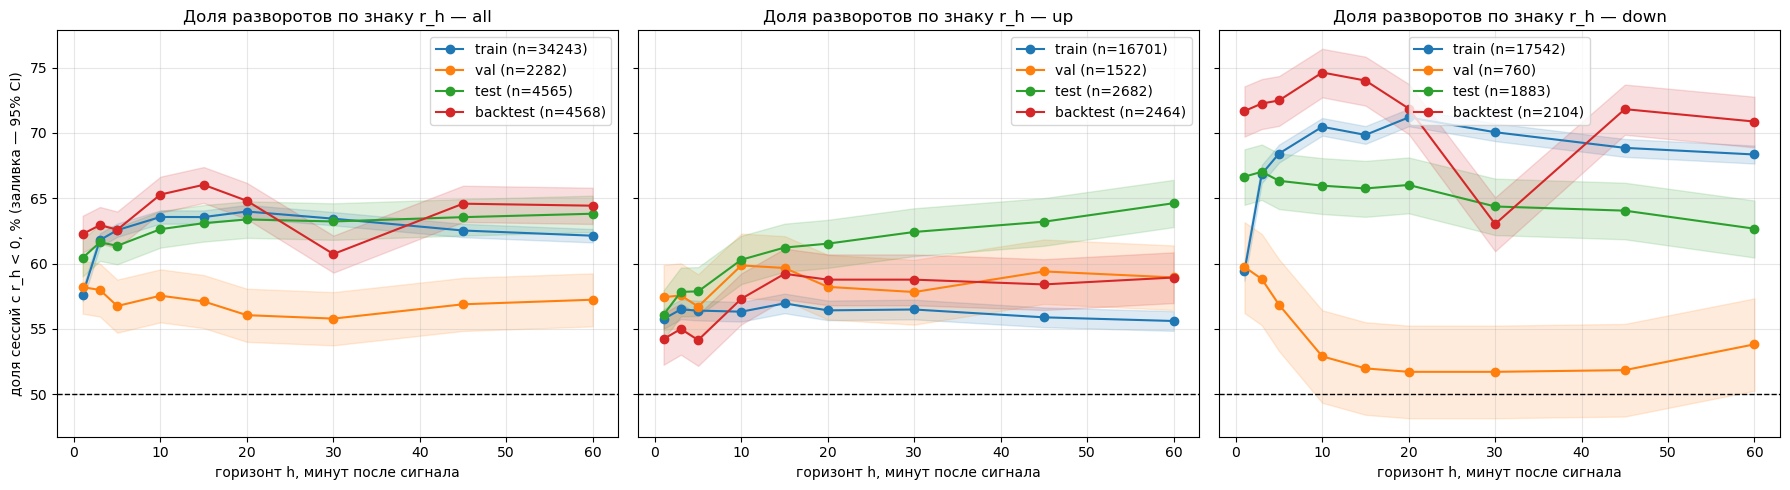

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, w in zip(axes, ['all', 'up', 'down']):
    for s in SPLITS:
        t = dir_sign[w][dir_sign[w]['split'] == s]
        ax.plot(t['h'], t['reversal'] * 100, marker='o', color=SPLIT_COLORS[s], label=f"{s} (n={t['n'].iloc[0]})")
        ax.fill_between(t['h'], t['ci_lo'] * 100, t['ci_hi'] * 100, color=SPLIT_COLORS[s], alpha=0.15)
    ax.axhline(50, color='k', ls='--', lw=1)
    ax.set_title(f'Доля разворотов по знаку r_h — {w}')
    ax.set_xlabel('горизонт h, минут после сигнала')
    ax.grid(alpha=0.3)
    ax.legend()
axes[0].set_ylabel('доля сессий с r_h < 0, % (заливка — 95% CI)')
plt.tight_layout()
plt.show()

**Траектории.** Ось x — минуты относительно сигнальной свечи (0 = индекс 89; вертикальный пунктир −10 — начало сигнального движения). Первая фигура: слева средняя подписанная траектория, в центре — медиана с полосой IQR, справа — медиана в долях `M` (значение −0.2 = «отдано 20% сигнала»). Участок до 0 показывает само сигнальное движение (по построению траектория идёт от ≈ −M к 0). Вторая фигура — медианы с IQR отдельно для up- и down-сигналов.


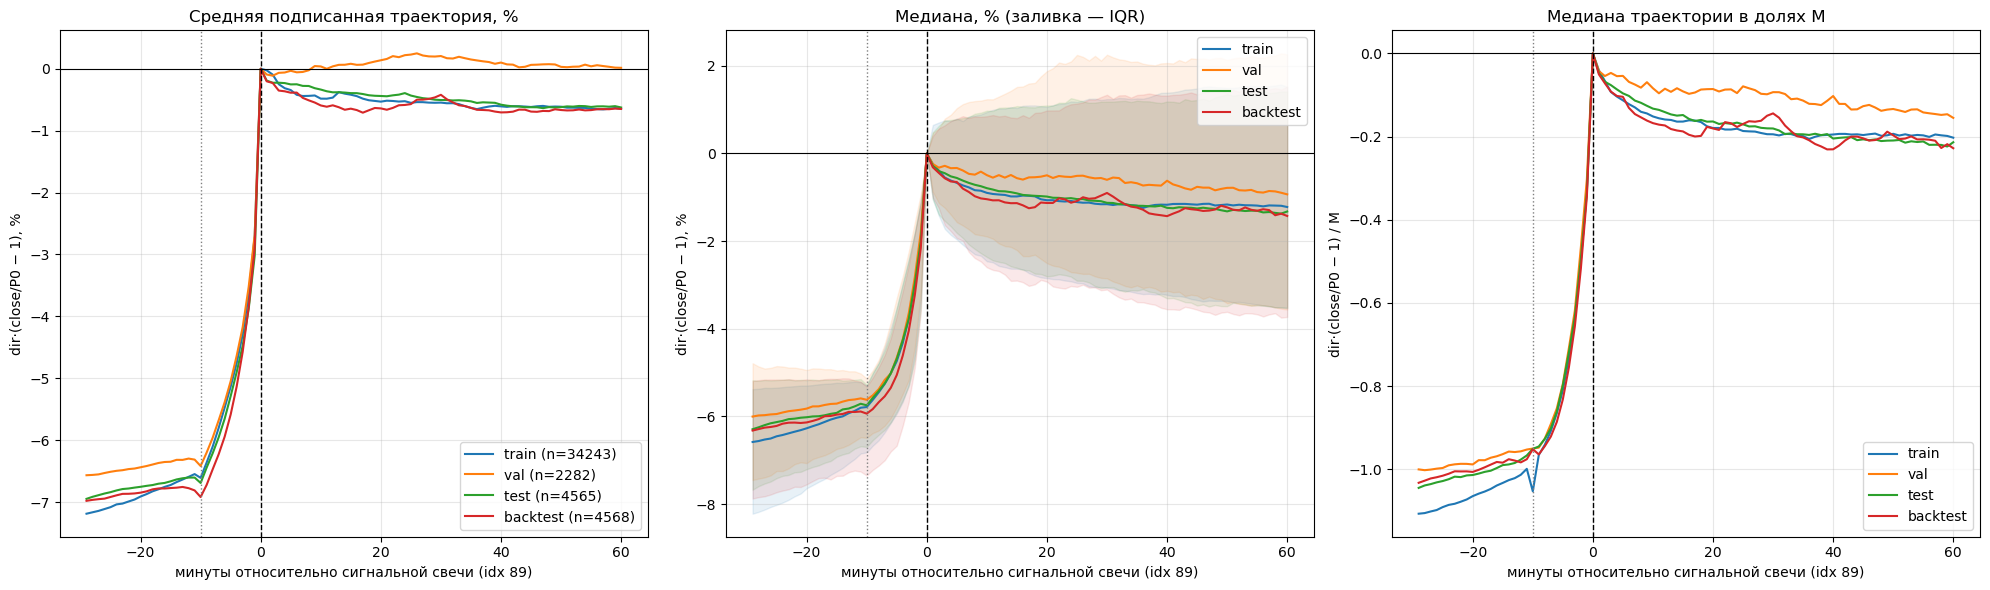

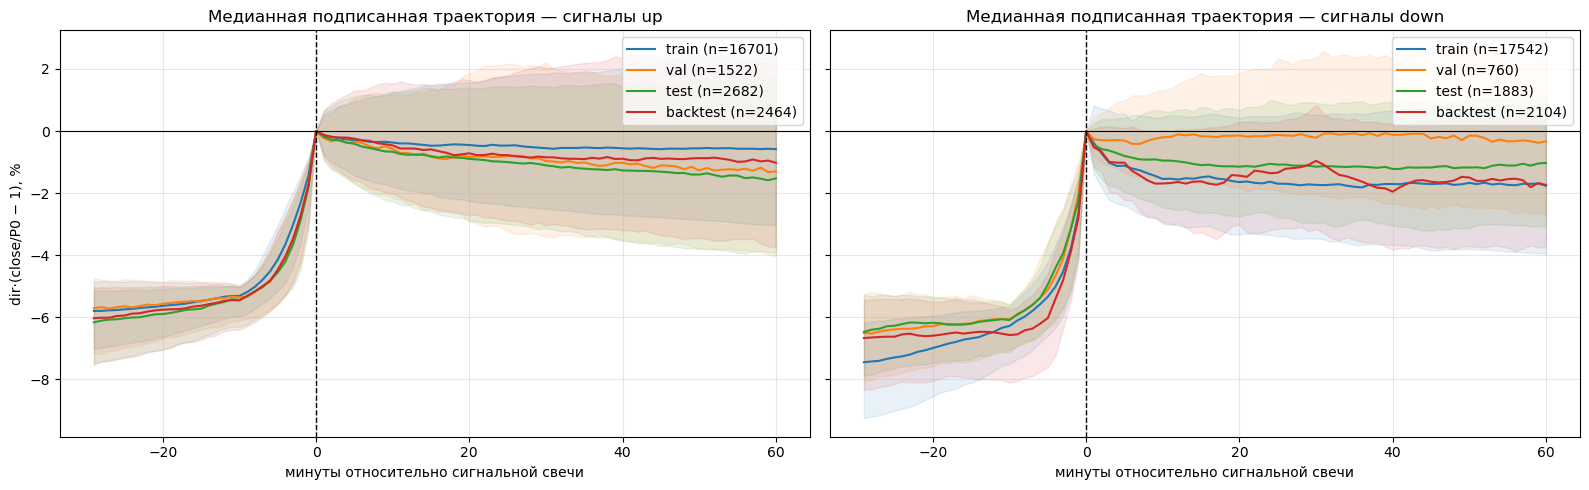

In [10]:
PATH_START = 60
paths = {s: signed_path(X[s], PATH_START) for s in SPLITS}
x_min = np.arange(PATH_START, SEQ_LEN) - SIGNAL_IDX

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for s in SPLITS:
    p = paths[s] * 100
    axes[0].plot(x_min, p.mean(0), color=SPLIT_COLORS[s], label=f'{s} (n={len(p)})')
    med = np.median(p, 0)
    q25, q75 = np.percentile(p, [25, 75], axis=0)
    axes[1].plot(x_min, med, color=SPLIT_COLORS[s], label=s)
    axes[1].fill_between(x_min, q25, q75, color=SPLIT_COLORS[s], alpha=0.10)
    M_s = df.loc[df['split'] == s, 'M'].values[:, None]
    axes[2].plot(x_min, np.median(paths[s] / M_s, 0), color=SPLIT_COLORS[s], label=s)
titles = ['Средняя подписанная траектория, %', 'Медиана, % (заливка — IQR)', 'Медиана траектории в долях M']
ylabels = ['dir·(close/P0 − 1), %', 'dir·(close/P0 − 1), %', 'dir·(close/P0 − 1) / M']
for ax, ttl, yl in zip(axes, titles, ylabels):
    ax.axvline(0, color='k', ls='--', lw=1)
    ax.axvline(-10, color='gray', ls=':', lw=1)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(ttl)
    ax.set_xlabel('минуты относительно сигнальной свечи (idx 89)')
    ax.set_ylabel(yl)
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, (w, cond) in zip(axes, [('up', 1), ('down', -1)]):
    for s in SPLITS:
        m = df.loc[df['split'] == s, 'dir'].values == cond
        p = paths[s][m] * 100
        med = np.median(p, 0)
        q25, q75 = np.percentile(p, [25, 75], axis=0)
        ax.plot(x_min, med, color=SPLIT_COLORS[s], label=f'{s} (n={m.sum()})')
        ax.fill_between(x_min, q25, q75, color=SPLIT_COLORS[s], alpha=0.10)
    ax.axvline(0, color='k', ls='--', lw=1)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(f'Медианная подписанная траектория — сигналы {w}')
    ax.set_xlabel('минуты относительно сигнальной свечи')
    ax.grid(alpha=0.3)
    ax.legend()
axes[0].set_ylabel('dir·(close/P0 − 1), %')
plt.tight_layout()
plt.show()

**Составные столбцы.** Доли трёх классов через 60 минут по сплитам (числа внутри столбцов — проценты); зелёное — продолжение, серое — flat, красное — разворот.


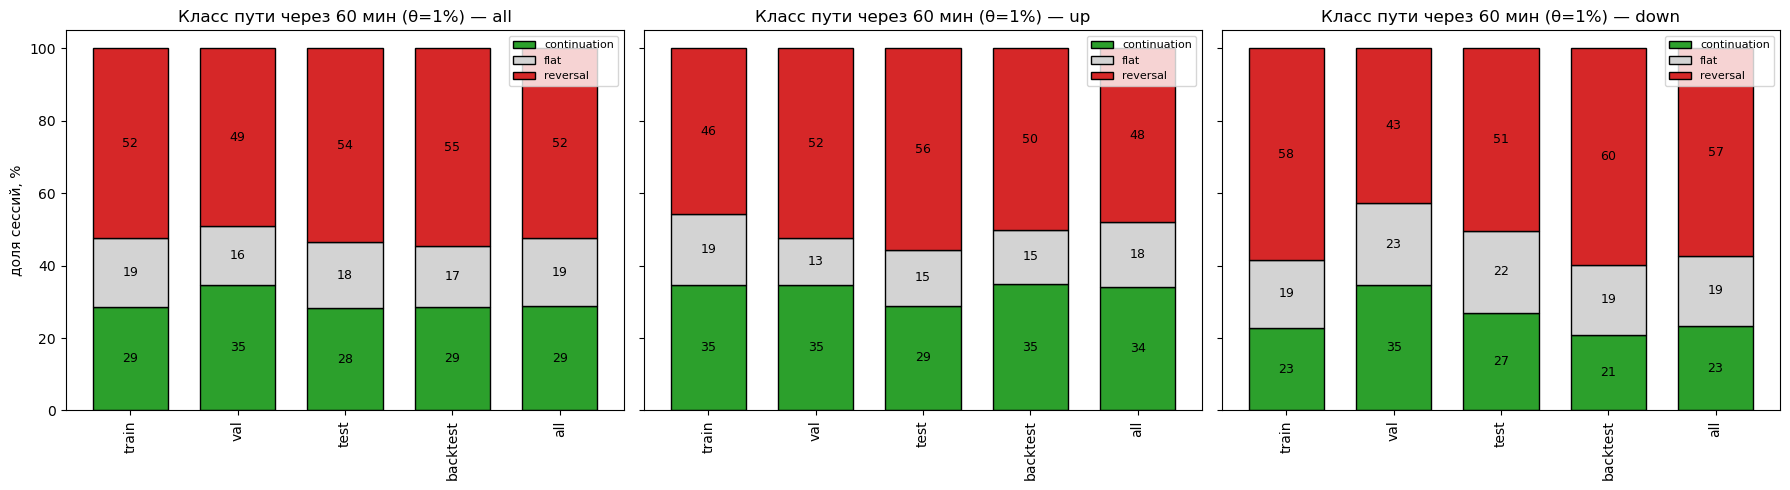

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, w in zip(axes, ['all', 'up', 'down']):
    t = dir_theta[w][dir_theta[w]['h'] == 60].set_index('split')[['continuation', 'flat', 'reversal']] * 100
    t.plot(kind='bar', stacked=True, ax=ax, color=['tab:green', 'lightgray', 'tab:red'], edgecolor='k', width=0.7)
    for i, (_, row) in enumerate(t.iterrows()):
        cum = 0
        for val in row:
            ax.text(i, cum + val / 2, f'{val:.0f}', ha='center', va='center', fontsize=9)
            cum += val
    ax.set_title(f'Класс пути через 60 мин (θ={THETA*100:g}%) — {w}')
    ax.set_xlabel('')
    ax.legend(loc='upper right', fontsize=8)
axes[0].set_ylabel('доля сессий, %')
plt.tight_layout()
plt.show()

## B. Резкость движения после сигнала

**Вопрос раздела:** насколько велики продолжение и откат по сравнению с самим сигналом, содержит ли пост-окно движения того же масштаба, зависит ли глубина отката от силы сигнала и насколько быстро всё происходит.

### MFE и MAE
Понятия *maximum favorable / adverse excursion* пришли из анализа сделок (J. Sweeney, «Maximum Adverse Excursion: Analyzing Price Fluctuations for Trading Management», Wiley, 1996): для каждой сделки смотрят, насколько далеко цена уходила в её пользу и против неё. Здесь «сделка» — условная позиция по направлению сигнала, открытая по `P0`: `MFE` — максимум `dir·(экстремум/P0 − 1)` по пост-окну, `MAE` — максимум в противоположную сторону. Оба неотрицательны и считаются по `high` / `low` (внутриминутные экстремумы). Для контртрендовой позиции роли меняются: её потенциальная прибыль — `MAE`, её риск — `MFE`.

### Квантили и CDF
[Квантиль](https://ru.wikipedia.org/wiki/Квантиль) `q90` — значение, ниже которого лежат 90% сессий (`q50` — медиана). Таблицы квантилей показывают и «типичное» (q50), и «хвостовое» (q90, q95) поведение; большой разрыв между средним и медианой — признак тяжёлого хвоста. [Эмпирическая функция распределения](https://en.wikipedia.org/wiki/Empirical_distribution_function) (CDF) на графиках — доля сессий со значением ≤ x: чем правее кривая, тем больше значения; чем круче — тем сильнее они сконцентрированы. Пример чтения: если кривая MAE проходит через точку (5%, 0.75), то у 75% сессий максимальный откат не превышает 5%, у 25% — глубже.

### Нормировка на M
`MFE/M` и `MAE/M` делают сессии с разным размером сигнала сравнимыми: `MAE/M = 0.5` — цена отдала половину сигнального движения, `1.0` — вернулась к цене до сигнала, `MFE/M = 1.0` — прошла ещё столько же, сколько прошла за сигнал.

### Ретриггер
Проверяем, есть ли в пост-окне 10-минутное движение close ≥ 5% — тот же критерий, по которому детектор нашёл сам сигнал. `same | retrigger` — условная доля: среди сессий с ретриггером какая часть движений идёт по направлению сигнала. Это ответ на вопрос «сколько сессий разворачиваются (или продолжают) *так же резко*, как двигались».

### Зависимость от силы сигнала
Сессии разбиваются на корзины по `M` функцией [`pandas.cut`](https://pandas.pydata.org/docs/reference/api/pandas.cut.html) (интервалы `[5, 6)`, `[6, 8)`, `[8, 12)`, `[12, ∞)` %). [Коэффициент ранговой корреляции Спирмена](https://en.wikipedia.org/wiki/Spearman%27s_rank_correlation_coefficient) `ρ ∈ [−1, 1]` измеряет монотонную связь между рангами величин; он устойчив к выбросам и нелинейности (реализация: [`scipy.stats.spearmanr`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html)). `ρ(M, MAE) ≈ 0.3` — слабая положительная связь (сильнее сигнал — глубже откат в процентах), `ρ(M, MAE/M) ≈ 0` — относительный откат от силы сигнала не зависит. [Hexbin](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hexbin.html) — двумерная гистограмма с шестиугольными ячейками и логарифмической цветовой шкалой; красная пунктирная линия `y = x` — «откат / продолжение равны сигналу».

### Скорость
Скорость сигнала = `M/10` (%/мин); скорость продолжения = `MFE/t_peak`, отката = `MAE/t_trough` — средняя скорость от `P0` до экстремума. Отношение `MAE_speed/signal_speed` показывает, во сколько раз откат медленнее сигнала; доля «разворот быстрее сигнала» — сколько сессий откатывают резче, чем двигались. Оговорка: при `t_peak = 1` скорость равна всей экскурсии за одну минуту, поэтому у ранних спайков она формально высокая — сравнивайте медианы и доли, а не средние.


**Квантили.** `quantile_table` считает q50 / q75 / q90 / q95 и среднее по каждому сплиту. Первая таблица — `M`, `MFE`, `MAE` и максимальное 10-минутное движение в % от `P0`; вторая — `MFE/M` и `MAE/M` в долях сигнала; третья — медианы и q90 MAE / MFE отдельно для up и down. `n` — число сессий в строке.


In [12]:
def quantile_table(frame, cols, qs=(0.5, 0.75, 0.9, 0.95), scale=100, which='all', names=None):
    rows = []
    for col in cols:
        for s in SPLITS_ALL:
            v = subset(frame[frame['split'] == s], which)[col].dropna().values * scale
            rows.append({'metric': names.get(col, col) if names else col, 'split': s, 'n': len(v),
                         **{f'q{int(q * 100)}': np.quantile(v, q) for q in qs}, 'mean': v.mean()})
    return pd.DataFrame(rows).set_index(['metric', 'split']).round(2)


SHARP_NAMES = {'M': 'M — сигнальное движение, %', 'mfe': 'MFE — макс. продолжение, %',
               'mae': 'MAE — макс. разворот, %', 'post_max10_abs': 'макс. |10-мин движение| после сигнала, %',
               'mfe_over_M': 'MFE / M', 'mae_over_M': 'MAE / M'}
print('Квантили размеров движений в пост-окне (по high/low относительно P0), %')
display(quantile_table(dfa, ['M', 'mfe', 'mae', 'post_max10_abs'], names=SHARP_NAMES))
print('То же в долях сигнального движения M')
display(quantile_table(dfa, ['mfe_over_M', 'mae_over_M'], scale=1, names=SHARP_NAMES))
print('MAE и MFE отдельно для up- и down-сигналов (медиана и q90), %')
rows = []
for w in ['up', 'down']:
    for s in SPLITS_ALL:
        sub = subset(dfa[dfa['split'] == s], w)
        rows.append({'dir': w, 'split': s, 'n': len(sub),
                     'MAE q50': sub['mae'].median() * 100, 'MAE q90': sub['mae'].quantile(0.9) * 100,
                     'MFE q50': sub['mfe'].median() * 100, 'MFE q90': sub['mfe'].quantile(0.9) * 100,
                     'MAE/M q50': sub['mae_over_M'].median(), 'MFE/M q50': sub['mfe_over_M'].median()})
display(pd.DataFrame(rows).set_index(['dir', 'split']).round(2))

Квантили размеров движений в пост-окне (по high/low относительно P0), %


n   q50   q75    q90    q95  mean
metric                                   split                                          
M — сигнальное движение, %               train     34243  5.75  6.68   8.37   9.89  6.40
                                         val        2282  5.68  6.54   8.29   9.97  6.64
                                         test       4565  5.75  6.70   8.51  10.52  6.58
                                         backtest   4568  5.94  7.21   9.37  11.41  6.96
                                         all       45658  5.76  6.72   8.46  10.10  6.49
MFE — макс. продолжение, %               train     34243  2.83  6.15  11.86  16.03  4.77
                                         val        2282  2.92  6.15  11.47  16.69  4.90
                                         test       4565  2.50  5.44  10.37  15.00  4.46
                                         backtest   4568  2.55  5.79  11.20  15.83  4.74
                                         all       45658  2.77  6.04  11.64  15.95  4.74
MAE — макс. разворот, %                  train     34243  3.24  5.07   7.35   9.19  3.85
                                         val        2282  3.24  5.31   7.75   9.56  3.94
                                         test       4565  3.46  5.37   8.08  10.56  4.23
                                         backtest   4568  3.55  5.59   8.57  11.67  4.51
                                         all       45658  3.29  5.16   7.54   9.55  3.96
макс. |10-мин движение| после сигнала, % train     34243  3.83  5.76   9.37  12.45  4.99
                                         val        2282  3.79  5.66   8.51  11.07  4.85
                                         test       4565  3.69  5.76   8.80  11.96  4.91
                                         backtest   4568  3.83  5.97   9.48  12.66  5.18
                                         all       45658  3.81  5.77   9.27  12.36  4.99

То же в долях сигнального движения M


n   q50   q75   q90   q95  mean
metric  split                                        
MFE / M train     34243  0.46  0.98  1.83  2.52  0.75
        val        2282  0.46  1.02  1.80  2.58  0.77
        test       4565  0.41  0.88  1.59  2.28  0.69
        backtest   4568  0.40  0.90  1.63  2.31  0.70
        all       45658  0.45  0.96  1.78  2.49  0.74
MAE / M train     34243  0.53  0.80  1.11  1.34  0.60
        val        2282  0.51  0.85  1.21  1.49  0.62
        test       4565  0.56  0.84  1.21  1.52  0.65
        backtest   4568  0.55  0.83  1.25  1.60  0.66
        all       45658  0.54  0.81  1.14  1.39  0.61

MAE и MFE отдельно для up- и down-сигналов (медиана и q90), %


n  MAE q50  MAE q90  MFE q50  MFE q90  MAE/M q50  MFE/M q50
dir  split                                                                    
up   train     16701     2.88     6.68     2.88    10.16       0.48       0.48
     val        1522     3.48     7.84     2.98    11.78       0.56       0.47
     test       2682     3.70     8.44     2.89    11.85       0.60       0.46
     backtest   2464     3.59     9.31     3.40    13.88       0.58       0.56
     all       23369     3.06     7.21     2.93    10.82       0.51       0.49
down train     17542     3.57     7.92     2.79    13.15       0.57       0.44
     val         760     2.72     7.34     2.83    10.42       0.46       0.45
     test       1883     3.14     7.34     2.01     8.18       0.51       0.33
     backtest   2104     3.50     7.66     1.80     7.67       0.53       0.29
     all       22289     3.50     7.86     2.61    12.37       0.56       0.41

**Ретриггеры.** `retrigger, %` — доля сессий с 10-минутным движением ≥ 5% в пост-окне; `same dir` / `opp dir` — доли таких движений по и против сигнала от всех сессий; `same | retrigger` — условная доля среди ретриггеров; далее медиана величины этого движения и медиана минуты его окончания (10 = движение пришлось на первые 10 минут).


In [13]:
rows = []
for w in ['all', 'up', 'down']:
    for s in SPLITS_ALL:
        sub = subset(dfa[dfa['split'] == s], w)
        rt = sub['retrigger']
        rows.append({'subset': w, 'split': s, 'n': len(sub),
                     'retrigger, %': rt.mean() * 100,
                     'same dir, %': sub['retrigger_same'].mean() * 100,
                     'opp dir, %': sub['retrigger_opp'].mean() * 100,
                     'same | retrigger, %': sub.loc[rt, 'retrigger_same'].mean() * 100,
                     'median |move| если retrigger, %': sub.loc[rt, 'post_max10_abs'].median() * 100,
                     'median минута окончания': sub.loc[rt, 'post_max10_t_end'].median()})
retrig = pd.DataFrame(rows).set_index(['subset', 'split']).round(1)
print(f'«Ретриггер»: в пост-окне есть 10-минутное движение close ≥ {RETRIGGER_THR*100:g}% (порог детектора сигналов)')
display(retrig)

«Ретриггер»: в пост-окне есть 10-минутное движение close ≥ 5% (порог детектора сигналов)


n  retrigger, %  same dir, %  opp dir, %  same | retrigger, %  median |move| если retrigger, %  median минута окончания
subset split                                                                                                                                
all    train     34243          32.2         14.2        18.0                 44.0                              7.4                     15.0
       val        2282          32.0         19.1        12.8                 59.9                              6.9                     19.0
       test       4565          31.8         15.5        16.3                 48.7                              7.2                     17.0
       backtest   4568          33.5         15.8        17.8                 47.0                              7.4                     20.0
       all       45658          32.3         14.7        17.6                 45.5                              7.3                     16.0
up     train     16701          27.4         17.9         9.5                 65.4                              6.7                     19.0
       val        1522          34.4         20.1        14.3                 58.4                              6.8                     19.0
       test       2682          38.9         19.2        19.7                 49.4                              7.2                     18.0
       backtest   2464          44.7         22.8        21.9                 51.1                              7.6                     21.0
       all       23369          31.0         18.7        12.3                 60.4                              6.9                     20.0
down   train     17542          36.7         10.6        26.2                 28.8                              8.2                     13.0
       val         760          27.1         17.2         9.9                 63.6                              7.4                     20.0
       test       1883          21.7         10.2        11.5                 46.9                              7.0                     16.0
       backtest   2104          20.4          7.5        13.0                 36.5                              7.1                     14.0
       all       22289          33.6         10.5        23.1                 31.1                              8.0                     13.0

**CDF по сплитам.** Верхний ряд — `MFE`, `MAE` (в %) и подписанное максимальное 10-минутное движение (> 0 — по сигналу); нижний — `MFE/M`, `MAE/M` и `r_60`. Оси x обрезаны (`xlim`) для читаемости — хвосты уходят дальше. Кривая правее = значения больше; ступенька у 5% на графике 10-минутного движения — порог ретриггера.


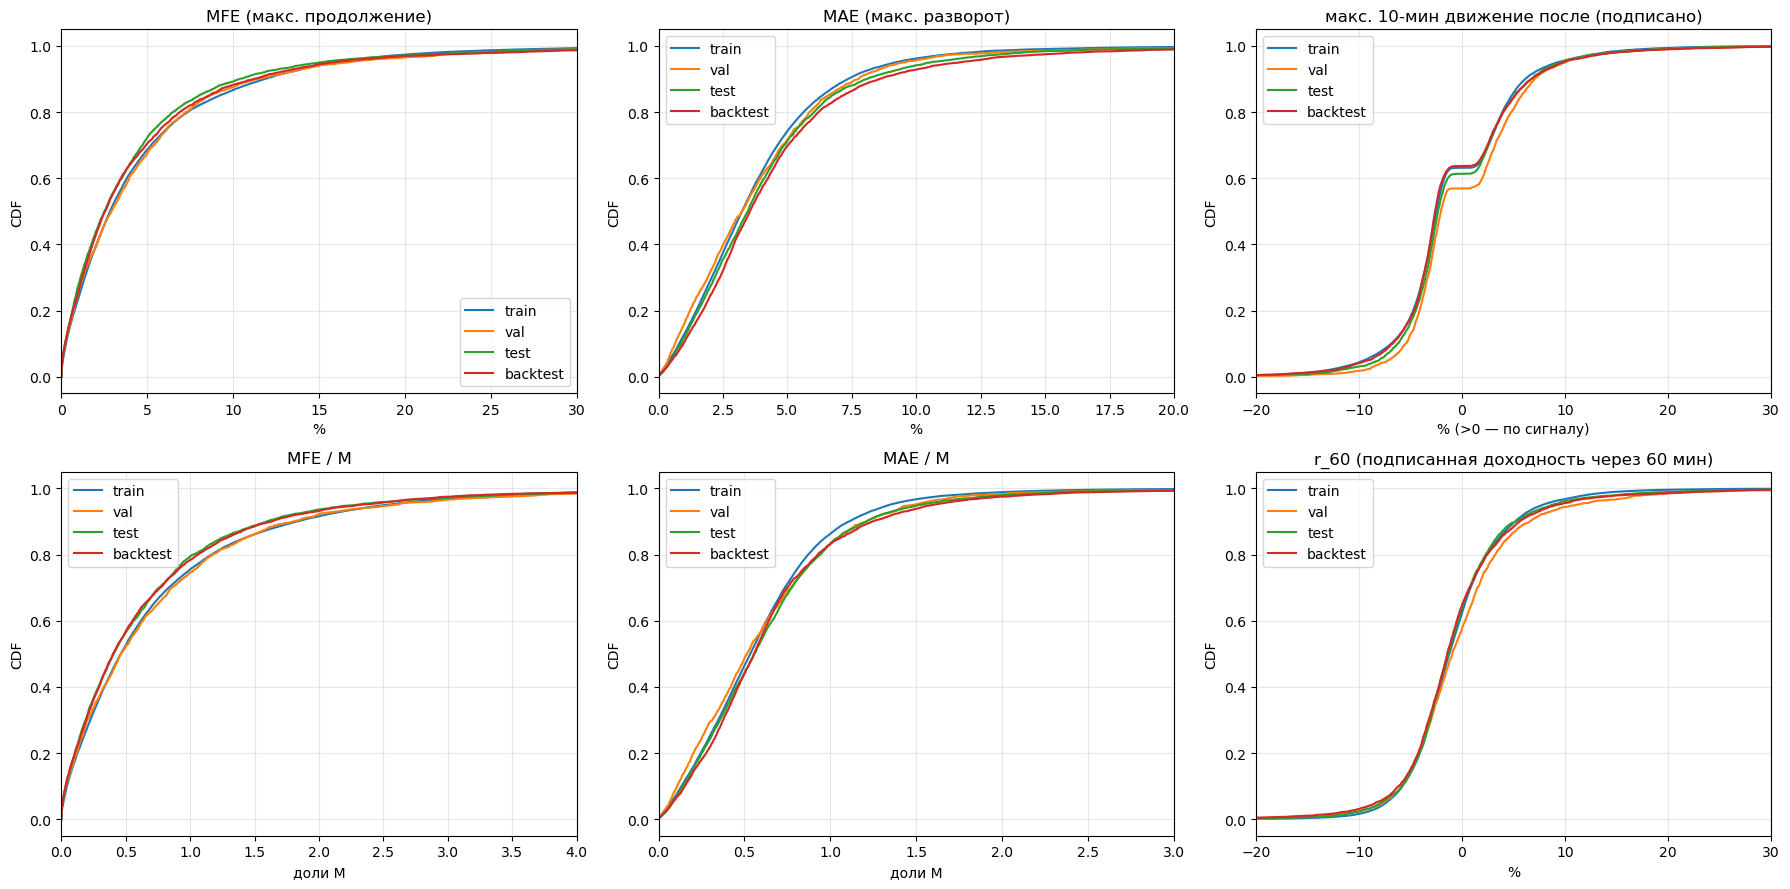

In [14]:
def plot_cdfs(frame, cols, titles, xlabels, scale, ncols=3, xlim=None):
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows))
    for ax, col, ttl, xl, sc in zip(axes.flat, cols, titles, xlabels, scale):
        for s in SPLITS:
            v = np.sort(frame.loc[frame['split'] == s, col].dropna().values * sc)
            ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=SPLIT_COLORS[s], label=s)
        ax.set_title(ttl)
        ax.set_xlabel(xl)
        ax.set_ylabel('CDF')
        ax.grid(alpha=0.3)
        ax.legend()
        if xlim is not None and xlim.get(col) is not None:
            ax.set_xlim(*xlim[col])
    plt.tight_layout()
    plt.show()


plot_cdfs(df, ['mfe', 'mae', 'post_max10_signed', 'mfe_over_M', 'mae_over_M', 'r_60'],
          ['MFE (макс. продолжение)', 'MAE (макс. разворот)', 'макс. 10-мин движение после (подписано)',
           'MFE / M', 'MAE / M', 'r_60 (подписанная доходность через 60 мин)'],
          ['%', '%', '% (>0 — по сигналу)', 'доли M', 'доли M', '%'],
          [100, 100, 100, 1, 1, 100],
          xlim={'mfe': (0, 30), 'mae': (0, 20), 'post_max10_signed': (-20, 30), 'mfe_over_M': (0, 4), 'mae_over_M': (0, 3), 'r_60': (-20, 30)})

**Зависимость от силы сигнала.** Таблица по корзинам `M`: `n`, медианы MAE и MFE (в %), медиана `MAE/M`, доля разворотов по знаку через 60 мин, доли отката ≥ 0.5·M, полного отката и продолжения ≥ 1·M (в %). Затем ρ Спирмена между `M` и MAE / MFE / MAE-over-M по сплитам и hexbin-диаграммы для train (оси обрезаны 5–30%; цвет — log10 числа сессий в ячейке).


Зависимость отката/продолжения от силы сигнала M (медианы, %; доли, %)


n  MAE_med  MFE_med  MAE_over_M_med  reversal60  rev_half_M  full_retrace  cont_1M
split    M_bin                                                                                        
train    5–6%   20242     2.77     2.47            0.51       59.96       51.30         13.74    23.53
         6–8%    9945     3.67     3.10            0.55       63.70       55.58         14.38    26.59
         8–12%   3351     5.34     4.92            0.57       67.56       58.82         12.35    26.17
         >12%     705     8.83     5.05            0.61       76.45       64.40          9.65    13.76
val      5–6%    1399     2.76     2.51            0.51       56.83       50.89         18.30    25.80
         6–8%     637     3.48     3.50            0.51       55.89       51.33         15.86    26.69
         8–12%    184     5.17     3.95            0.54       64.13       57.07          9.78    21.20
         >12%      62     7.49     5.30            0.49       59.68       46.77          8.06    19.35
test     5–6%    2677     2.92     2.26            0.55       62.35       54.54         17.41    20.73
         6–8%    1310     3.93     2.60            0.59       66.56       59.62         16.26    19.92
         8–12%    421     4.82     4.03            0.53       64.61       53.44         15.20    23.28
         >12%     157     8.20     5.28            0.49       63.69       49.68         12.74    15.92
backtest 5–6%    2375     2.90     2.39            0.54       62.19       54.53         18.02    22.95
         6–8%    1416     3.87     2.35            0.57       68.36       58.26         14.90    19.92
         8–12%    584     5.23     3.26            0.58       65.75       59.93         16.95    20.89
         >12%     193     7.60     7.13            0.45       59.07       47.67         15.03    20.73
all      5–6%   26693     2.80     2.44            0.52       60.23       51.89         14.73    23.32
         6–8%   13308     3.71     2.98            0.56       64.10       56.06         14.69    25.23
         8–12%   4540     5.29     4.62            0.57       66.92       58.39         13.11    25.02
         >12%    1117     8.53     5.33            0.58       70.73       58.46         10.92    15.58

Spearman ρ между M и MAE / MFE по сплитам


,"rho(M, MAE)","rho(M, MFE)","rho(M, MAE/M)"
split,,,
train,0.282,0.157,0.043
val,0.236,0.151,0.002
test,0.271,0.097,0.019
backtest,0.301,0.079,0.015
all,0.282,0.142,0.037


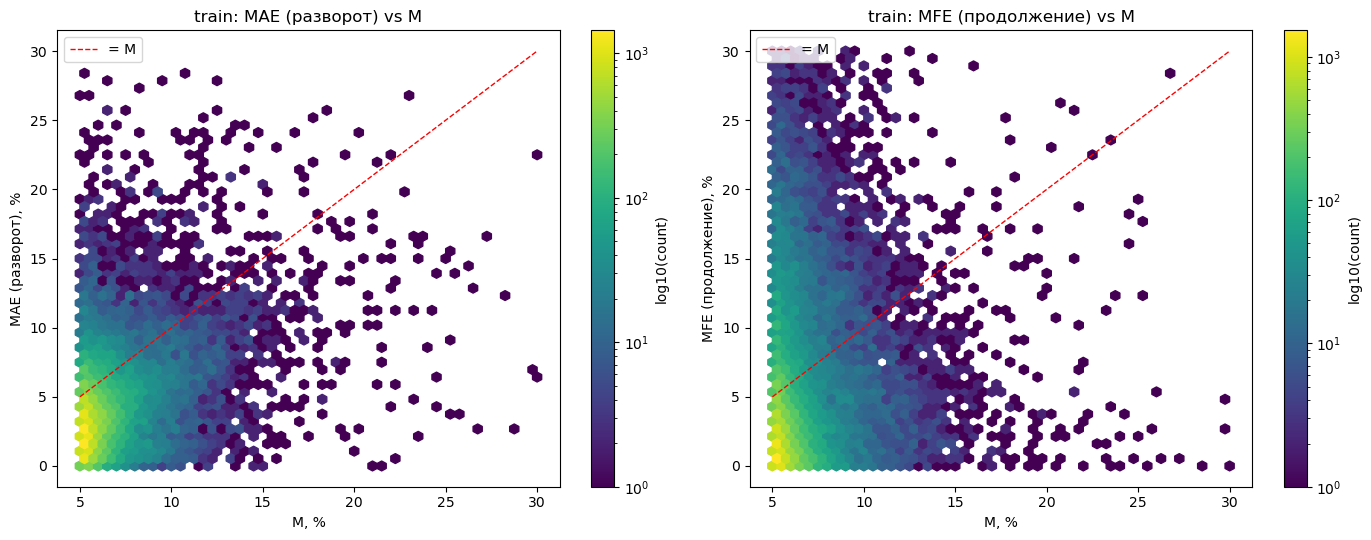

In [15]:
M_BINS = [0.05, 0.06, 0.08, 0.12, np.inf]
M_LABELS = ['5–6%', '6–8%', '8–12%', '>12%']
dfa['M_bin'] = pd.cut(dfa['M'], bins=M_BINS, labels=M_LABELS, right=False)
df['M_bin'] = pd.cut(df['M'], bins=M_BINS, labels=M_LABELS, right=False)

print('Зависимость отката/продолжения от силы сигнала M (медианы, %; доли, %)')
dep = dfa.groupby(['split', 'M_bin'], observed=True).agg(
    n=('M', 'size'),
    MAE_med=('mae', lambda x: x.median() * 100),
    MFE_med=('mfe', lambda x: x.median() * 100),
    MAE_over_M_med=('mae_over_M', 'median'),
    reversal60=('r_60', lambda x: np.mean(x < 0) * 100),
    rev_half_M=('t_rev_0.5M', lambda x: x.notna().mean() * 100),
    full_retrace=('t_rev_1M', lambda x: x.notna().mean() * 100),
    cont_1M=('t_cont_1M', lambda x: x.notna().mean() * 100),
).round(2)
display(dep)

print('Spearman ρ между M и MAE / MFE по сплитам')
rows = []
for s in SPLITS_ALL:
    sub = dfa[dfa['split'] == s]
    rows.append({'split': s, 'rho(M, MAE)': stats.spearmanr(sub['M'], sub['mae'])[0],
                 'rho(M, MFE)': stats.spearmanr(sub['M'], sub['mfe'])[0],
                 'rho(M, MAE/M)': stats.spearmanr(sub['M'], sub['mae_over_M'])[0]})
display(pd.DataFrame(rows).set_index('split').round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sub = df[df['split'] == 'train']
for ax, col, ttl in zip(axes, ['mae', 'mfe'], ['MAE (разворот)', 'MFE (продолжение)']):
    hb = ax.hexbin(sub['M'] * 100, sub[col] * 100, gridsize=50, bins='log', extent=(5, 30, 0, 30), cmap='viridis')
    ax.plot([5, 30], [5, 30], 'r--', lw=1, label='= M')
    ax.set_title(f'train: {ttl} vs M')
    ax.set_xlabel('M, %')
    ax.set_ylabel(f'{ttl}, %')
    ax.legend()
    plt.colorbar(hb, ax=ax, label='log10(count)')
plt.tight_layout()
plt.show()

**Скорости.** Медианы скоростей (%/мин) сигнала, продолжения до пика и отката до впадины; отношения скоростей к скорости сигнала; доли сессий, в которых откат / продолжение были быстрее самого сигнала.


In [16]:
rows = []
for s in SPLITS_ALL:
    sub = dfa[dfa['split'] == s]
    rows.append({'split': s,
                 'скорость сигнала, %/мин (медиана)': sub['signal_speed'].median() * 100,
                 'скорость продолжения до пика, %/мин': sub['mfe_speed'].median() * 100,
                 'скорость разворота до впадины, %/мин': sub['mae_speed'].median() * 100,
                 'MFE_speed / signal_speed (медиана)': (sub['mfe_speed'] / sub['signal_speed']).median(),
                 'MAE_speed / signal_speed (медиана)': (sub['mae_speed'] / sub['signal_speed']).median(),
                 'доля: разворот быстрее сигнала, %': np.mean(sub['mae_speed'] > sub['signal_speed']) * 100,
                 'доля: продолжение быстрее сигнала, %': np.mean(sub['mfe_speed'] > sub['signal_speed']) * 100})
print('Резкость как скорость: экскурсия / время до экстремума против скорости сигнала M/10')
display(pd.DataFrame(rows).set_index('split').round(3))

Резкость как скорость: экскурсия / время до экстремума против скорости сигнала M/10


,"скорость сигнала, %/мин (медиана)","скорость продолжения до пика, %/мин","скорость разворота до впадины, %/мин",MFE_speed / signal_speed (медиана),MAE_speed / signal_speed (медиана),"доля: разворот быстрее сигнала, %","доля: продолжение быстрее сигнала, %"
split,,,,,,,
train,0.575,0.364,0.172,0.603,0.272,15.644,37.041
val,0.568,0.282,0.182,0.448,0.297,17.485,26.556
test,0.575,0.336,0.181,0.540,0.289,16.539,31.895
backtest,0.594,0.324,0.206,0.498,0.318,14.317,31.283
all,0.576,0.350,0.176,0.573,0.279,15.693,35.426


## C. Длительность

**Вопрос раздела:** когда наступают экстремумы пост-окна, за сколько минут цена откатывает на долю сигнала или на фиксированный процент, и какая доля сессий так и не достигает уровня за 60 минут.

### Время до события и цензурирование
Для каждой сессии и каждого уровня записана минута его первого достижения (`t_rev_*`, `t_cont_*`). Если уровень не достигнут — `NaN`. В терминах [анализа выживаемости](https://en.wikipedia.org/wiki/Survival_analysis) такие наблюдения **цензурированы справа**: мы знаем только, что событие не произошло за 60 минут. Поскольку у всех сессий одинаковый горизонт наблюдения, «кривая выживаемости» (доля сессий, ещё не достигших уровня к минуте `m`) считается просто как `1 − доля(t_hit ≤ m)`; в общем случае с разными горизонтами использовали бы [оценку Каплана — Мейера](https://en.wikipedia.org/wiki/Kaplan%E2%80%93Meier_estimator).

Два следствия для чтения таблиц:
- «Медиана минуты достижения» считается **только среди достигших**. Если полный откат случился в 14% сессий, его медианное время (≈ 28 мин) описывает только эти 14%.
- `t_peak` / `t_trough` — минута глобального экстремума в окне. Если `t_trough` близко к 60, откат, скорее всего, ещё продолжался бы за пределами окна (эффект усечения).

### Что показывают графики
- Кривые «ещё не достигли»: значение 46% на 60-й минуте для уровня `0.5·M` означает, что 46% сессий за час не откатили и половины сигнала; крутизна кривой в начале — как быстро «отваливаются» сессии, достигшие уровня. Верхний ряд — откат, нижний — продолжение; вторая фигура — откат на абсолютные 1 / 2 / 3 / 5%.
- Гистограммы `t_peak` / `t_trough` с `density=True` (площадь под гистограммой = 1) показывают, на какие минуты приходятся экстремумы: пик на 1-й минуте — мгновенная реакция после сигнальной свечи, подъём к 60-й — усечение окна.
- `new extreme after 10m / 30m` — доля сессий, у которых максимум продолжения обновлялся после 10-й / 30-й минуты: мера того, как долго «живёт» импульс.


**Минуты экстремумов.** Квантили q25 / q50 / q75 (в минутах) `t_peak` и `t_trough`; `n` меньше числа сессий, потому что у сессий без экскурсии (`MFE = 0` или `MAE = 0`) время не определено. Вторая таблица — медианы для up / down и доли сессий, обновлявших максимум продолжения после 10-й и 30-й минуты.


In [17]:
print('Минуты до экстремумов пост-окна (t_peak — макс. продолжение, t_trough — макс. разворот)')
display(quantile_table(dfa, ['t_peak', 't_trough'], qs=(0.25, 0.5, 0.75), scale=1))
print('То же для up / down сигналов (медианы)')
rows = []
for w in ['up', 'down']:
    for s in SPLITS_ALL:
        sub = subset(dfa[dfa['split'] == s], w)
        rows.append({'dir': w, 'split': s, 't_peak q50': sub['t_peak'].median(), 't_trough q50': sub['t_trough'].median(),
                     'new extreme after 10m, %': sub['new_extreme_after_10'].mean() * 100,
                     'new extreme after 30m, %': sub['new_extreme_after_30'].mean() * 100})
display(pd.DataFrame(rows).set_index(['dir', 'split']).round(1))

Минуты до экстремумов пост-окна (t_peak — макс. продолжение, t_trough — макс. разворот)


n  q25   q50   q75   mean
metric   split                                  
t_peak   train     33499  1.0   6.0  28.0  16.44
         val        2197  2.0  12.0  34.0  19.99
         test       4418  1.0   7.0  29.0  16.79
         backtest   4433  1.0   7.0  33.0  18.14
         all       44547  1.0   7.0  29.0  16.82
t_trough train     34098  5.0  22.0  46.0  25.71
         val        2274  4.0  21.0  46.0  25.58
         test       4547  6.0  23.0  45.0  25.86
         backtest   4554  7.0  19.0  42.0  25.03
         all       45473  5.0  21.0  45.0  25.65

То же для up / down сигналов (медианы)


t_peak q50  t_trough q50  new extreme after 10m, %  new extreme after 30m, %
dir  split                                                                                 
up   train           14.0          21.0                      54.5                      32.7
     val             10.0          23.0                      47.0                      26.0
     test             8.0          24.0                      45.1                      25.1
     backtest        12.0          21.0                      52.4                      32.0
     all             13.0          21.0                      52.7                      31.3
down train            3.0          23.0                      30.8                      13.5
     val             16.0          17.0                      55.5                      31.6
     test             5.0          21.0                      37.8                      19.4
     backtest         2.0          17.0                      33.6                      21.1
     all              3.0          22.0                      32.5                      15.3

**Уровни.** Для каждого сплита — доля сессий, достигших уровня за 60 минут (в %), и медиана минуты первого достижения среди достигших. Первые три столбца — уровни в долях `M` (0.25, 0.5, 1), остальные — абсолютные 1 / 2 / 3 / 5% от `P0`. Сначала откат (экскурсия против сигнала), потом продолжение.


In [18]:
def level_tables(frame, kind):
    share_rows, time_rows = [], []
    for s in SPLITS_ALL:
        sub = frame[frame['split'] == s]
        sr, tr = {'split': s, 'n': len(sub)}, {'split': s}
        for k in K_LEVELS:
            t = sub[f't_{kind}_{level_tag(k)}']
            sr[f'≥{k:g}·M'] = t.notna().mean() * 100
            tr[f'≥{k:g}·M'] = t.median()
        for a in ABS_LEVELS:
            t = sub[f't_{kind}_{abs_tag(a)}']
            sr[f'≥{a*100:g}%'] = t.notna().mean() * 100
            tr[f'≥{a*100:g}%'] = t.median()
        share_rows.append(sr)
        time_rows.append(tr)
    return pd.DataFrame(share_rows).set_index('split').round(1), pd.DataFrame(time_rows).set_index('split').round(1)


for kind, name in [('rev', 'РАЗВОРОТ (экскурсия против сигнала от P0)'), ('cont', 'ПРОДОЛЖЕНИЕ (экскурсия по сигналу от P0)')]:
    share, tmed = level_tables(dfa, kind)
    print(f'{name}: доля сессий, достигших уровня за 60 минут, %')
    display(share)
    print(f'{name}: медиана минуты первого достижения уровня (среди достигших)')
    display(tmed)

РАЗВОРОТ (экскурсия против сигнала от P0): доля сессий, достигших уровня за 60 минут, %


,n,≥0.25·M,≥0.5·M,≥1·M,≥1%,≥2%,≥3%,≥5%
split,,,,,,,,
train,34243,79.5,53.5,13.7,87.1,71.0,53.9,25.8
val,2282,75.8,51.4,16.7,84.0,68.5,52.5,28.4
test,4565,80.1,55.7,16.7,88.2,72.8,57.2,28.7
backtest,4568,82.0,56.1,16.8,89.5,75.6,58.5,30.3
all,45658,79.6,53.9,14.5,87.3,71.5,54.6,26.6


РАЗВОРОТ (экскурсия против сигнала от P0): медиана минуты первого достижения уровня (среди достигших)


,≥0.25·M,≥0.5·M,≥1·M,≥1%,≥2%,≥3%,≥5%
split,,,,,,,
train,3.0,9.0,29.0,1.0,4.0,8.0,19.0
val,4.0,12.0,27.0,2.0,6.0,11.0,21.0
test,3.0,10.0,25.0,1.0,4.0,9.0,17.0
backtest,3.0,11.0,24.0,2.0,4.0,9.0,16.0
all,3.0,10.0,28.0,1.0,4.0,8.0,18.0


ПРОДОЛЖЕНИЕ (экскурсия по сигналу от P0): доля сессий, достигших уровня за 60 минут, %


,n,≥0.25·M,≥0.5·M,≥1·M,≥1%,≥2%,≥3%,≥5%
split,,,,,,,,
train,34243,67.5,47.4,24.5,76.1,60.6,48.1,31.4
val,2282,66.4,48.0,25.5,74.4,61.0,49.3,32.5
test,4565,63.4,43.5,20.6,72.1,56.2,44.5,27.8
backtest,4568,63.8,43.2,21.7,74.0,57.3,44.8,29.5
all,45658,66.7,46.6,23.9,75.4,59.8,47.5,30.9


ПРОДОЛЖЕНИЕ (экскурсия по сигналу от P0): медиана минуты первого достижения уровня (среди достигших)


,≥0.25·M,≥0.5·M,≥1·M,≥1%,≥2%,≥3%,≥5%
split,,,,,,,
train,2.0,5.0,10.0,1.0,3.0,5.0,7.0
val,3.0,8.0,15.0,2.0,5.0,8.0,12.0
test,3.0,6.0,11.0,2.0,3.0,5.0,8.0
backtest,3.0,6.0,13.0,2.0,3.0,5.0,9.0
all,2.0,6.0,10.0,2.0,3.0,5.0,7.0


**Кривые «ещё не достигли».** Для каждой минуты `m` — доля сессий, у которых уровень к этой минуте ещё не достигнут (`1 − CDF` времени достижения). Первая фигура: верхний ряд — откат на 0.25 / 0.5 / 1·M, нижний — продолжение; вторая — откат на абсолютные 1 / 2 / 3 / 5%. Значение на 60-й минуте = 100% − доля достигших из таблицы выше.


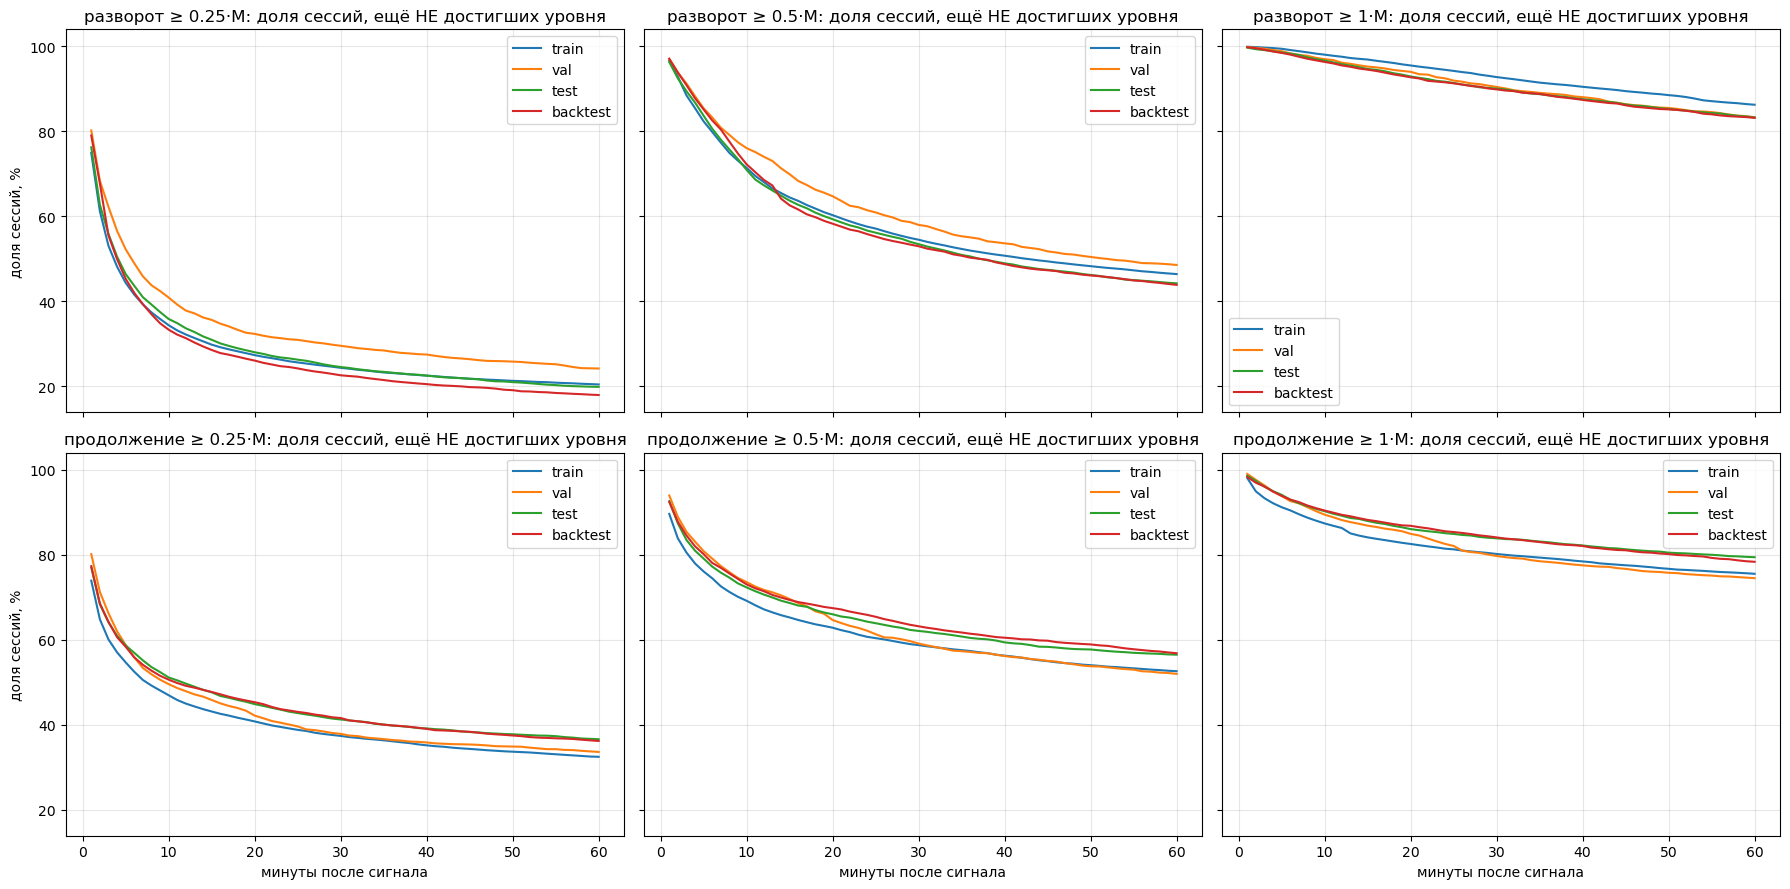

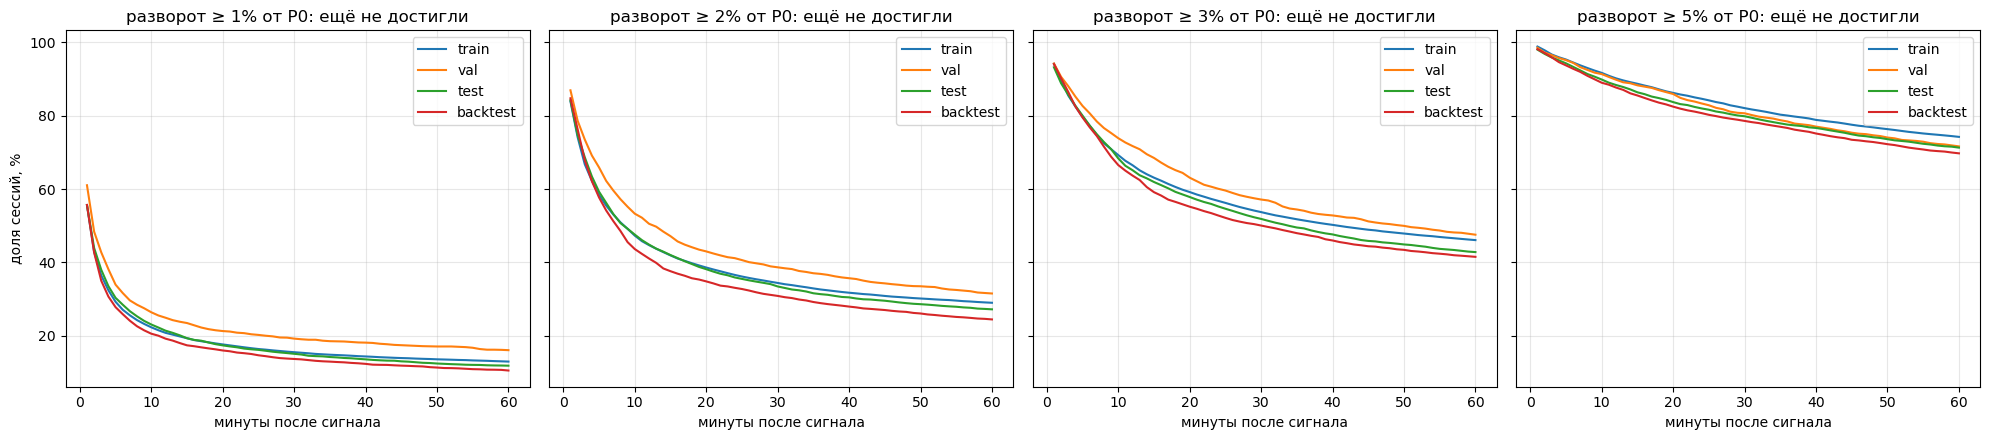

In [19]:
minutes = np.arange(1, POST_LEN + 1)
fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True, sharey=True)
for row, (kind, name) in enumerate([('rev', 'разворот'), ('cont', 'продолжение')]):
    for ax, k in zip(axes[row], K_LEVELS):
        for s in SPLITS:
            t = df.loc[df['split'] == s, f't_{kind}_{level_tag(k)}'].values
            not_yet = [np.mean(~(t <= m)) * 100 for m in minutes]
            ax.plot(minutes, not_yet, color=SPLIT_COLORS[s], label=s)
        ax.set_title(f'{name} ≥ {k:g}·M: доля сессий, ещё НЕ достигших уровня')
        ax.grid(alpha=0.3)
        ax.legend()
        if row == 1:
            ax.set_xlabel('минуты после сигнала')
    axes[row][0].set_ylabel('доля сессий, %')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)
for ax, a in zip(axes, ABS_LEVELS):
    for s in SPLITS:
        t = df.loc[df['split'] == s, f't_rev_{abs_tag(a)}'].values
        ax.plot(minutes, [np.mean(~(t <= m)) * 100 for m in minutes], color=SPLIT_COLORS[s], label=s)
    ax.set_title(f'разворот ≥ {a*100:g}% от P0: ещё не достигли')
    ax.set_xlabel('минуты после сигнала')
    ax.grid(alpha=0.3)
    ax.legend()
axes[0].set_ylabel('доля сессий, %')
plt.tight_layout()
plt.show()

**Гистограммы минут экстремумов.** Плотность (`density=True`) по минутам 1…60 для каждого сплита; пик на первой минуте — мгновенная реакция, рост к 60-й — усечение окна.


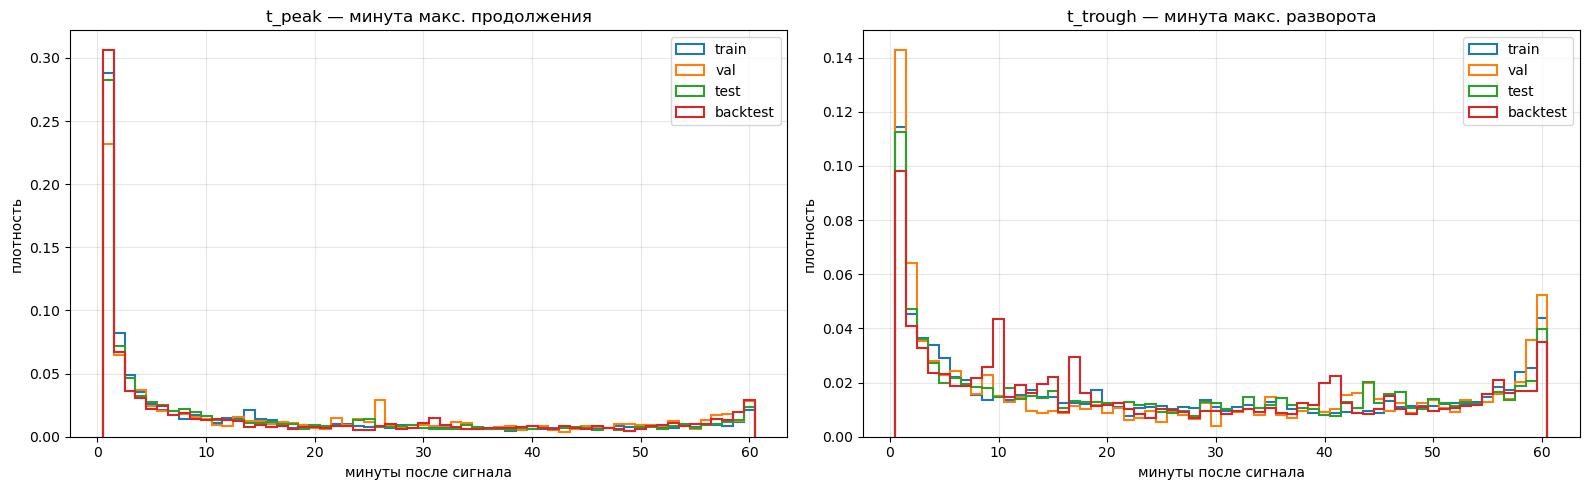

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, col, ttl in zip(axes, ['t_peak', 't_trough'], ['t_peak — минута макс. продолжения', 't_trough — минута макс. разворота']):
    for s in SPLITS:
        v = df.loc[df['split'] == s, col].dropna().values
        ax.hist(v, bins=np.arange(0.5, POST_LEN + 1.5, 1), density=True, histtype='step', lw=1.5, color=SPLIT_COLORS[s], label=s)
    ax.set_title(ttl)
    ax.set_xlabel('минуты после сигнала')
    ax.set_ylabel('плотность')
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

## D. Сравнение train vs val / test / backtest

**Вопрос раздела:** одинаково ли ведёт себя цена после сигнала в разные периоды. Так как сплиты хронологические, различия между ними — это смена рыночного режима и состава инструментов, и именно это определяет, можно ли переносить статистику train на будущее.

### Как устроена проверка
Для каждой метрики сравнивается train (эталон, 34 тыс. сессий) с каждым из трёх остальных сплитов. Используется классическая схема [проверки статистических гипотез](https://ru.wikipedia.org/wiki/Проверка_статистических_гипотез): нулевая гипотеза `H0` — «в обоих периодах метрика одинакова»; [p-значение](https://ru.wikipedia.org/wiki/P-значение) — вероятность получить наблюдаемое (или большее) различие, если `H0` верна. Пороги: `*` — p < 0.05, `**` — p < 0.01.

- **Доли** (`тип = доля, %`): [z-тест двух долей](https://en.wikipedia.org/wiki/Z-test). Объединённая доля `p = (k1 + k2)/(n1 + n2)`, стандартная ошибка `se = sqrt(p(1−p)(1/n1 + 1/n2))`, статистика `z = (p̂1 − p̂2)/se`, двустороннее p-значение `2·(1 − Φ(|z|))`, где `Φ` — функция стандартного нормального распределения. Готовая реализация есть в [`statsmodels.stats.proportion.proportions_ztest`](https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportions_ztest.html).
- **Непрерывные величины** (`тип = медиана`): двухвыборочный [критерий Колмогорова — Смирнова](https://en.wikipedia.org/wiki/Kolmogorov%E2%80%93Smirnov_test) ([`scipy.stats.ks_2samp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ks_2samp.html)). Статистика `D = max_x |F_train(x) − F_split(x)|` — наибольшее расстояние между эмпирическими функциями распределения; тест непараметрический и реагирует на любое различие (сдвиг, разброс, форма). В таблице для наглядности приводятся медианы, но тест сравнивает распределения целиком.

### Как интерпретировать
1. **Значимость ≠ величина эффекта.** При `n` = 34 000 против 4 500 тест обнаруживает различия в доли процента. Поэтому смотрите на разницу самих значений (столбцы сплитов): сдвиг MAE с 3.24% до 3.46% значим, но мал; сдвиг доли разворотов с 62% до 57% (val) — уже существенно для стратегии. Подробнее: [effect size](https://en.wikipedia.org/wiki/Effect_size).
2. **Множественные сравнения.** 31 метрика × 3 сплита = 93 теста. Даже если бы различий не было, при α = 0.05 ожидалось бы ~4–5 «значимых» результатов по чистой случайности ([проблема множественных сравнений](https://en.wikipedia.org/wiki/Multiple_comparisons_problem)). Строгая [поправка Бонферрони](https://en.wikipedia.org/wiki/Bonferroni_correction) дала бы порог 0.05/93 ≈ 0.0005; на практике ориентируйтесь на `**` и на согласованность направления сдвига между test и backtest.
3. **Зависимость наблюдений.** Одновременные сигналы по многим тикерам (раздел E) означают, что эффективное число независимых наблюдений меньше `n`, и p-значения занижены. Это ещё один довод смотреть на величину эффекта.
4. **Состав сплитов.** Доля up-сигналов — первая строка сводной таблицы — различается сильно; поэтому ниже те же ключевые метрики приведены отдельно для up и down.

Счётчик «Число метрик со значимым отличием» и столбчатая диаграмма дают общее впечатление: какой сплит дальше всего от train.


**Сводная таблица сравнения.** Словарь `PROP_METRICS` задаёт булевы признаки (по ним считаются доли и z-тест), `CONT_METRICS` — непрерывные признаки (столбец и множитель для перевода в %; по ним — медианы и KS-тест). `comparison_table` собирает значения по сплитам, p-значения «train против сплита» и флаги значимости; `show_comparison` форматирует вывод. Строки — метрики, столбцы — значения по сплитам, `p(...)` и `sig(...)`.


In [21]:
PROP_METRICS = {
    'up-сигналы': lambda f: f['dir'] > 0,
    'разворот по знаку @10м (r_10<0)': lambda f: f['r_10'] < 0,
    'разворот по знаку @60м (r_60<0)': lambda f: f['r_60'] < 0,
    f'continuation @60м (r_60≥{THETA*100:g}%)': lambda f: f['r_60'] >= THETA,
    f'reversal @60м (r_60≤−{THETA*100:g}%)': lambda f: f['r_60'] <= -THETA,
    'разворот ≥0.25·M за 60м': lambda f: f['t_rev_0.25M'].notna(),
    'разворот ≥0.5·M за 60м': lambda f: f['t_rev_0.5M'].notna(),
    'полный откат (≥1·M)': lambda f: f['t_rev_1M'].notna(),
    'продолжение ≥0.5·M': lambda f: f['t_cont_0.5M'].notna(),
    'продолжение ≥1·M': lambda f: f['t_cont_1M'].notna(),
    'разворот ≥2% (abs)': lambda f: f['t_rev_2pct'].notna(),
    'разворот ≥5% (abs)': lambda f: f['t_rev_5pct'].notna(),
    'продолжение ≥5% (abs)': lambda f: f['t_cont_5pct'].notna(),
    'ретриггер (10-мин ≥5%)': lambda f: f['retrigger'],
    'ретриггер по сигналу': lambda f: f['retrigger_same'],
    'ретриггер против сигнала': lambda f: f['retrigger_opp'],
    'V-shape (MFE≥0.5M и r_60<0)': lambda f: f['v_shape'],
    'новый экстремум продолжения после 30м': lambda f: f['new_extreme_after_30'],
}
CONT_METRICS = {  # name: (column, scale, unit)
    'M, %': ('M', 100), 'r_10, %': ('r_10', 100), 'r_60, %': ('r_60', 100),
    'MFE, %': ('mfe', 100), 'MAE, %': ('mae', 100), 'MFE/M': ('mfe_over_M', 1), 'MAE/M': ('mae_over_M', 1),
    'макс. |10-мин| после, %': ('post_max10_abs', 100),
    't_peak, мин': ('t_peak', 1), 't_trough, мин': ('t_trough', 1),
    't до разворота 0.5·M, мин': ('t_rev_0.5M', 1), 't до продолжения 0.5·M, мин': ('t_cont_0.5M', 1),
    'pre-drift (idx 0→79, подписан), %': ('pre_drift', 100),
}


def two_prop_ztest(k1, n1, k2, n2):
    p = (k1 + k2) / (n1 + n2)
    se = np.sqrt(p * (1 - p) * (1 / n1 + 1 / n2))
    if se == 0:
        return np.nan
    z = (k1 / n1 - k2 / n2) / se
    return 2 * (1 - stats.norm.cdf(abs(z)))


def comparison_table(frame, which='all', prop_metrics=PROP_METRICS, cont_metrics=CONT_METRICS, base='train'):
    subs = {s: subset(frame[frame['split'] == s], which) for s in SPLITS}
    others = [s for s in SPLITS if s != base]
    rows = []
    for name, fn in prop_metrics.items():
        vals = {s: fn(subs[s]).astype(bool) for s in SPLITS}
        row = {'metric': name, 'type': 'доля, %'}
        row.update({s: vals[s].mean() * 100 for s in SPLITS})
        for s in others:
            row[f'p({s})'] = two_prop_ztest(vals[base].sum(), len(vals[base]), vals[s].sum(), len(vals[s]))
        rows.append(row)
    for name, (col, sc) in cont_metrics.items():
        vals = {s: subs[s][col].dropna().values * sc for s in SPLITS}
        row = {'metric': name, 'type': 'медиана'}
        row.update({s: np.median(vals[s]) for s in SPLITS})
        for s in others:
            row[f'p({s})'] = stats.ks_2samp(vals[base], vals[s]).pvalue
        rows.append(row)
    out = pd.DataFrame(rows).set_index(['metric', 'type'])
    for s in others:
        out[f'sig({s})'] = np.where(out[f'p({s})'] < 0.01, '**', np.where(out[f'p({s})'] < 0.05, '*', ''))
    return out


def show_comparison(tbl):
    t = tbl.copy()
    for c in t.columns:
        if c.startswith('p('):
            t[c] = t[c].map(lambda v: f'{v:.3f}' if v >= 0.001 else '<0.001')
        elif c in SPLITS:
            t[c] = t[c].round(2)
    display(t)


print('n сессий:', {s: int((df['split'] == s).sum()) for s in SPLITS})
print('Сводная таблица train vs val/test/backtest. Доли — z-тест двух долей, медианы — KS-тест распределений (train против сплита). * p<0.05, ** p<0.01')
cmp_all = comparison_table(df, 'all')
show_comparison(cmp_all)

n сессий: {'train': 34243, 'val': 2282, 'test': 4565, 'backtest': 4568}
Сводная таблица train vs val/test/backtest. Доли — z-тест двух долей, медианы — KS-тест распределений (train против сплита). * p<0.05, ** p<0.01


,,train,val,test,backtest,p(val),p(test),p(backtest),sig(val),sig(test),sig(backtest)
metric,type,,,,,,,,,,
up-сигналы,"доля, %",48.77,66.70,58.75,53.94,<0.001,<0.001,<0.001,**,**,**
разворот по знаку @10м (r_10<0),"доля, %",63.56,57.54,62.63,65.28,<0.001,0.218,0.023,**,,*
разворот по знаку @60м (r_60<0),"доля, %",62.13,57.23,63.81,64.43,<0.001,0.028,0.003,**,*,**
continuation @60м (r_60≥1%),"доля, %",28.63,34.66,28.17,28.55,<0.001,0.521,0.909,**,,
reversal @60м (r_60≤−1%),"доля, %",52.25,49.17,53.60,54.64,0.004,0.086,0.002,**,,**
разворот ≥0.25·M за 60м,"доля, %",79.51,75.77,80.09,82.01,<0.001,0.367,<0.001,**,,**
разворот ≥0.5·M за 60м,"доля, %",53.55,51.40,55.73,56.09,0.046,0.006,0.001,*,**,**
полный откат (≥1·M),"доля, %",13.70,16.65,16.71,16.79,<0.001,<0.001,<0.001,**,**,**
продолжение ≥0.5·M,"доля, %",47.39,48.03,43.50,43.17,0.557,<0.001,<0.001,,**,**


**По направлениям.** Те же тесты для ключевых метрик отдельно по up- и down-сигналам — чтобы отделить смену поведения цены от смены состава сплитов.


In [22]:
KEY_PROPS = {k: PROP_METRICS[k] for k in ['разворот по знаку @60м (r_60<0)', 'разворот ≥0.5·M за 60м', 'полный откат (≥1·M)',
                                          'продолжение ≥1·M', 'разворот ≥5% (abs)', 'ретриггер (10-мин ≥5%)', 'V-shape (MFE≥0.5M и r_60<0)']}
KEY_CONT = {k: CONT_METRICS[k] for k in ['M, %', 'r_60, %', 'MFE, %', 'MAE, %', 't_trough, мин', 't до разворота 0.5·M, мин']}
for w in ['up', 'down']:
    print(f'--- сигналы {w} ---')
    show_comparison(comparison_table(df, w, KEY_PROPS, KEY_CONT))

--- сигналы up ---


,,train,val,test,backtest,p(val),p(test),p(backtest),sig(val),sig(test),sig(backtest)
metric,type,,,,,,,,,,
разворот по знаку @60м (r_60<0),"доля, %",55.60,58.94,64.62,58.93,0.012,<0.001,0.002,*,**,**
разворот ≥0.5·M за 60м,"доля, %",48.21,55.52,59.10,57.51,<0.001,<0.001,<0.001,**,**,**
полный откат (≥1·M),"доля, %",12.31,18.73,20.40,21.14,<0.001,<0.001,<0.001,**,**,**
продолжение ≥1·M,"доля, %",23.72,26.81,25.02,29.79,0.007,0.144,<0.001,**,,**
разворот ≥5% (abs),"доля, %",21.48,32.00,33.30,33.52,<0.001,<0.001,<0.001,**,**,**
ретриггер (10-мин ≥5%),"доля, %",27.42,34.43,38.93,44.72,<0.001,<0.001,<0.001,**,**,**
V-shape (MFE≥0.5M и r_60<0),"доля, %",12.27,13.21,17.49,18.06,0.287,<0.001,<0.001,,**,**
"M, %",медиана,5.61,5.66,5.76,5.77,0.048,<0.001,<0.001,*,**,**
"r_60, %",медиана,-0.58,-1.30,-1.53,-1.02,<0.001,<0.001,<0.001,**,**,**


--- сигналы down ---


,,train,val,test,backtest,p(val),p(test),p(backtest),sig(val),sig(test),sig(backtest)
metric,type,,,,,,,,,,
разворот по знаку @60м (r_60<0),"доля, %",68.34,53.82,62.67,70.87,<0.001,<0.001,0.019,**,**,*
разворот ≥0.5·M за 60м,"доля, %",58.63,43.16,50.93,54.42,<0.001,<0.001,<0.001,**,**,**
полный откат (≥1·M),"доля, %",15.03,12.50,11.47,11.69,0.055,<0.001,<0.001,,**,**
продолжение ≥1·M,"доля, %",25.19,22.89,14.23,12.12,0.153,<0.001,<0.001,,**,**
разворот ≥5% (abs),"доля, %",29.84,21.05,22.15,26.43,<0.001,<0.001,0.001,**,**,**
ретриггер (10-мин ≥5%),"доля, %",36.74,27.11,21.72,20.44,<0.001,<0.001,<0.001,**,**,**
V-shape (MFE≥0.5M и r_60<0),"доля, %",19.02,9.87,8.98,10.08,<0.001,<0.001,<0.001,**,**,**
"M, %",медиана,5.91,5.72,5.74,6.17,<0.001,<0.001,<0.001,**,**,**
"r_60, %",медиана,-1.76,-0.33,-1.03,-1.74,<0.001,<0.001,0.004,**,**,**


**Итог по дрейфу.** Число метрик со значимым отличием от train по каждому сплиту и столбчатая диаграмма ключевых долей по сплитам.


Число метрик со значимым (p<0.05) отличием от train:


,sig(val),sig(test),sig(backtest)
count,24,21,27


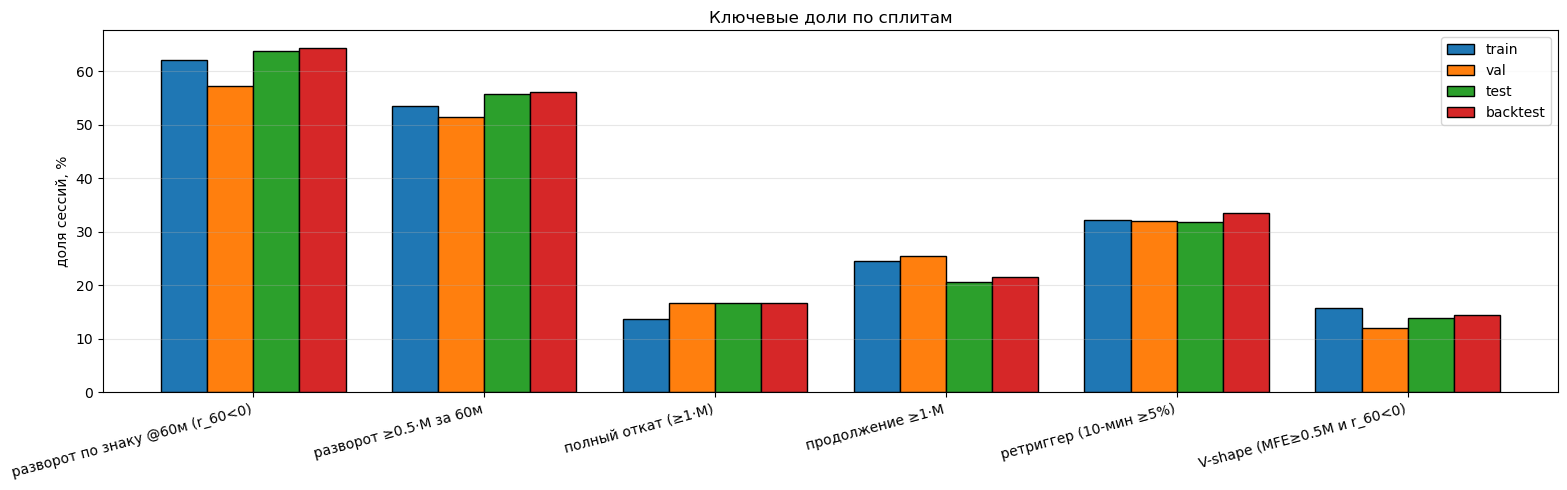

In [23]:
sig_cols = [c for c in cmp_all.columns if c.startswith('sig(')]
n_sig = (cmp_all[sig_cols] != '').sum()
print('Число метрик со значимым (p<0.05) отличием от train:')
display(n_sig.rename('count').to_frame().T)

key_rows = ['разворот по знаку @60м (r_60<0)', 'разворот ≥0.5·M за 60м', 'полный откат (≥1·M)', 'продолжение ≥1·M',
            'ретриггер (10-мин ≥5%)', 'V-shape (MFE≥0.5M и r_60<0)']
t = cmp_all.reset_index().set_index('metric').loc[key_rows, SPLITS]
ax = t.plot(kind='bar', figsize=(16, 5), color=[SPLIT_COLORS[s] for s in SPLITS], edgecolor='k', width=0.8)
ax.set_ylabel('доля сессий, %')
ax.set_title('Ключевые доли по сплитам')
ax.set_xlabel('')
plt.xticks(rotation=15, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## E. Симуляция мартингейла

**Вопрос раздела:** что даст простая мартингейл-сетка на этих сессиях — какой процент прибыльных сессий, какое матожидание после издержек, какой капитал нужен и насколько тяжёл хвост убытков.

### Что такое мартингейл и почему он «работает» на глаз
[Мартингейл как система ставок](https://en.wikipedia.org/wiki/Martingale_%28betting_system%29): после каждого проигрыша ставка удваивается, чтобы первый же выигрыш перекрыл все предыдущие потери. В трейдинге аналог — **усреднение с растущим объёмом**: если цена идёт против позиции, добавляют объём по худшей цене, средняя цена входа приближается к рынку, и небольшого отката хватает для выхода в плюс. Свойство системы: очень высокая доля прибыльных сделок и редкие, но огромные убытки, когда цена уходит дальше всей сетки. Управление размером само по себе не создаёт положительного матожидания — его может дать только статистическое преимущество (здесь — склонность к откату из разделов A–C); а требуемый капитал растёт экспоненциально с числом шагов ([risk of ruin](https://en.wikipedia.org/wiki/Risk_of_ruin), [gambler's ruin](https://en.wikipedia.org/wiki/Gambler%27s_ruin)).

### Модель (функция `simulate_martingale`)
Параметры: `side` (`counter` — позиция против сигнала: после пампа шорт, после дампа лонг; `trend` — по сигналу), `step` — шаг сетки в долях от `P0`, `mult` — множитель объёма докупок, `tp` — take-profit в долях от средней цены, `max_adds` — максимальное число докупок, `cost` — издержки на сторону.

Пошагово, на примере up-сигнала, `side = counter` (шорт), `P0 = 100`, `step = 2%`, `mult = 2`, `tp = 1%`, `max_adds = 4`:
1. Минута 0 (сигнальная свеча): шорт номиналом 1 по цене 100. `pos = −1` (для лонга `pos = +1`).
2. Уровни докупок `P0·(1 − pos·k·step)` = 102, 104, 106, 108; объёмы `mult^k` = 2, 4, 8, 16. Полная сетка = 1 + 2 + 4 + 8 + 16 = 31 = `max_capital`.
3. Каждую минуту `t = 1…60` проверяется, задел ли `high` (для шорта; `low` для лонга) очередной уровень: `levels = floor(adverse/step)`, где `adverse` — неблагоприятная экскурсия свечи от `P0`. Все новые уровни исполняются по цене уровня (в одной свече может сработать несколько).
4. Позиция учитывается двумя величинами: `notional` — сумма вложенных номиналов, `coins = Σ notional_k / price_k` — количество монет; средняя цена `avg = notional / coins`.
5. Take-profit: цена `avg·(1 + pos·tp)`; для шорта проверяется `low ≤ TP`, для лонга `high ≥ TP`. **В свече, где была докупка, TP не проверяется** (см. ниже). Выход фиксирует `t_exit`, `p_exit`.
6. Если TP не достигнут — принудительное закрытие по `close` минуты 60.
7. `PnL = coins·(p_exit − avg)·pos − cost·(notional + coins·p_exit)`: первое слагаемое — результат позиции (для лонга это `Σ notional·(p_exit/avg − 1)`), второе — издержки на все входы и на выход. При выходе по TP без докупок PnL ≈ `1·tp − 2·cost` ≈ 0.01 − 0.0013 = 0.0087 — это пик на гистограмме PnL.

Издержки: комиссия 0.04% + проскальзывание 0.025% на сторону — значения `MarketConfig.transaction_fee` и `MarketConfig.slippage` из `rl-trading-binance/config.py` ([slippage](https://en.wikipedia.org/wiki/Slippage_%28finance%29)).

**Единицы.** PnL и капитал измеряются в единицах номинала первого входа. Если первый вход — 100 USDT, то `mean_pnl = 0.014` означает +1.4 USDT на сессию в среднем, `max_capital = 31` — для полной сетки нужен 3100 USDT (без плеча), `worst_pnl = −72` — худшая сессия потеряла 7200 USDT (UNFIUSDT, 2022-06-07: цена за час выросла в 3.5–4.6 раза против шорта; на реальной бирже это была бы ликвидация).

**Порядок событий внутри свечи.** По OHLC неизвестно, что было раньше — `high` или `low`. Принята консервативная схема: докупки срабатывают раньше TP, и в свече с докупкой TP не проверяется (позиция может закрыться только со следующей минуты). Это слегка занижает результат; «оптимистичная» схема завышала бы его.

### Метрики (`summarize_sim`)
| метрика | смысл |
|---|---|
| `tp_rate`, % | доля сессий, закрытых по take-profit |
| `max_adds_hit`, % | доля сессий, в которых сетка заполнилась полностью (цена прошла все уровни) |
| `mean_adds` | среднее число докупок |
| `mean_pnl`, `median_pnl`, `sum_pnl` | средний / медианный / суммарный PnL на сессию (ед. номинала) |
| `q1_pnl`, `q5_pnl` | 1-й и 5-й процентили PnL: границы худших 1% и 5% сессий (аналог [VaR](https://en.wikipedia.org/wiki/Value_at_risk)) |
| `worst_pnl` | худшая сессия |
| `profit_factor` | сумма прибылей / сумма убытков; > 1 — стратегия в плюсе |
| `max_capital` | `Σ mult^k`, `k = 0…max_adds` — номинал при полной сетке |
| `ret_on_capital_pct` | `mean_pnl / max_capital · 100` — средняя доходность на зарезервированный капитал за одну сессию; позволяет сравнивать сетки разного размера |
| `forced_mean_pnl` | средний PnL сессий, закрытых принудительно |
| `mean_t_exit` | средняя минута выхода |

### Сетка параметров и переобучение
Перебираются 108 конфигураций (`side` × `step` ∈ {1, 2, 3}% × `mult` ∈ {1, 2} × `tp` ∈ {0.5, 1, 2}% × `max_adds` ∈ {3, 4, 5}) на каждом сплите. Выбор лучшей конфигурации на train и оценка её на val / test / backtest — проверка **вне выборки**: результат на train всегда завышен просто потому, что конфигурация выбрана по нему ([переобучение](https://ru.wikipedia.org/wiki/Переобучение); о переобучении бэктестов — Bailey, Borwein, López de Prado, Zhu, 2014, «Pseudo-Mathematics and Financial Charlatanism»). Корреляция Спирмена рангов конфигураций между train и другим сплитом показывает, сохраняется ли «ландшафт» параметров: ρ ≈ 1 — лучшие на train остаются лучшими; ρ ≈ 0 — ранжирование не переносится.

[Heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html): строки — `step`, столбцы — `tp`; верхний ряд — `ret_on_capital` (зелёное — лучше), нижний — `q1_pnl` (хвост: чем краснее, тем тяжелее худший 1% сессий). Гистограмма PnL построена в логарифмическом масштабе по оси y, чтобы был виден длинный левый хвост.

### Кластеризация сигналов и коррелированный риск
Резкие движения часто происходят одновременно по многим тикерам (общерыночные обвалы и ралли). Симуляция считает каждую сессию отдельно, но в реальности одновременные сессии требуют капитала **одновременно** (`max_capital` × число сессий) и проигрывают / выигрывают вместе — дисперсия суммарного результата гораздо больше, чем при независимых сессиях. Последняя ячейка раздела считает число сессий с одной и той же минутой сигнала и сравнивает долю разворотов в кластерах и у одиночных сигналов.

### Чего модель не учитывает
Плечо, ликвидации и ставку финансирования; лимиты позиции и частичные исполнения; проскальзывание сверх константы при исполнении уровней; ограничение капитала при параллельных сессиях; возможность закрыть позицию до 60-й минуты по иным правилам (стоп-лосс, трейлинг). Результаты — оценка для «чистой» сетки без риск-менеджмента.


**Симуляция: подготовка и базовая конфигурация.** Массивы `POST[split]` содержат `high` / `low` / `close` начиная с индекса 89 (позиция 0 — сигнальная свеча, 1…60 — пост-окно) и направление `dir`. Далее — функции `simulate_martingale` (векторная симуляция по всем сессиям сплита, алгоритм описан выше) и `summarize_sim` (метрики). Таблица — базовая конфигурация `BASE_CFG` для обеих сторон (`counter`, `trend`) по всем сплитам.


In [24]:
FEE = 0.0004        # MarketConfig.transaction_fee (на сторону)
SLIPPAGE = 0.00025  # MarketConfig.slippage
COST = FEE + SLIPPAGE

POST = {}
for s in SPLITS:
    POST[s] = {k: X[s][:, SIGNAL_IDX:, IDX[k]] for k in ['high', 'low', 'close']}   # позиции 0..60, 0 = сигнальная свеча
    POST[s]['dir'] = np.sign(X[s][:, SIGNAL_IDX, IDX['close']] - X[s][:, MOVE_START_IDX, IDX['close']])


def simulate_martingale(post, side='counter', step=0.02, mult=2.0, tp=0.01, max_adds=4, cost=COST):
    """
    Векторная симуляция мартингейла по всем сессиям сплита.
    - Вход по close сигнальной свечи (P0) номиналом 1.
    - side='counter' — позиция против сигнала (up-сигнал -> short), 'trend' — по сигналу.
    - k-я докупка при касании уровня P0*(1 - pos*k*step) номиналом mult**k, исполнение по цене уровня.
    - TP при касании avg*(1 + pos*tp) (по high/low). В свече, где была докупка, TP не проверяется (консервативно).
    - Принудительное закрытие по close минуты 60.
    PnL в единицах базового номинала, комиссии + проскальзывание на каждый вход и на выход.
    """
    h, l, c, d = post['high'], post['low'], post['close'], post['dir']
    N = len(c)
    P0 = c[:, 0]
    pos = -d if side == 'counter' else d
    notional = np.ones(N)
    coins = 1.0 / P0
    n_adds = np.zeros(N, dtype=int)
    active = np.ones(N, dtype=bool)
    t_exit = np.full(N, np.nan)
    p_exit = np.full(N, np.nan)
    is_tp = np.zeros(N, dtype=bool)

    for t in range(1, POST_LEN + 1):
        if not active.any():
            break
        hi, lo = h[:, t], l[:, t]
        adverse_ext = np.where(pos > 0, lo, hi)
        adverse = np.maximum(-pos * (adverse_ext / P0 - 1), 0)
        levels = np.minimum(np.floor(adverse / step + 1e-12).astype(int), max_adds)
        added = np.zeros(N, dtype=bool)
        while True:
            need = active & (levels > n_adds)
            if not need.any():
                break
            k = n_adds[need] + 1
            add_notional = mult ** k
            notional[need] += add_notional
            coins[need] += add_notional / (P0[need] * (1 - pos[need] * k * step))
            n_adds[need] = k
            added |= need
        avg = notional / coins
        fav_ext = np.where(pos > 0, hi, lo)
        tp_hit = active & ~added & (pos * (fav_ext / avg - 1) >= tp)
        t_exit[tp_hit] = t
        p_exit[tp_hit] = avg[tp_hit] * (1 + pos[tp_hit] * tp)
        is_tp |= tp_hit
        active &= ~tp_hit
    t_exit[active] = POST_LEN
    p_exit[active] = c[active, POST_LEN]
    avg = notional / coins
    gross = coins * (p_exit - avg) * pos
    costs = cost * (notional + coins * p_exit)
    return pd.DataFrame({'tp': is_tp, 't_exit': t_exit, 'n_adds': n_adds, 'pnl': gross - costs,
                         'notional': notional, 'dir': d.astype(int)})


def summarize_sim(res, max_adds, mult):
    max_capital = sum(mult ** k for k in range(max_adds + 1))
    pnl = res['pnl'].values
    gains, losses = pnl[pnl > 0].sum(), -pnl[pnl < 0].sum()
    forced = res.loc[~res['tp'], 'pnl']
    return {'n': len(res), 'tp_rate': res['tp'].mean() * 100, 'max_adds_hit': np.mean(res['n_adds'] >= max_adds) * 100,
            'mean_adds': res['n_adds'].mean(), 'mean_pnl': pnl.mean(), 'median_pnl': np.median(pnl), 'sum_pnl': pnl.sum(),
            'q1_pnl': np.quantile(pnl, 0.01), 'q5_pnl': np.quantile(pnl, 0.05), 'worst_pnl': pnl.min(),
            'profit_factor': gains / losses if losses > 0 else np.inf, 'max_capital': max_capital,
            'ret_on_capital_pct': 100 * pnl.mean() / max_capital,
            'forced_mean_pnl': forced.mean() if len(forced) else 0.0, 'mean_t_exit': res['t_exit'].mean()}


BASE_CFG = dict(step=0.02, mult=2.0, tp=0.01, max_adds=4)
print('Базовая конфигурация:', BASE_CFG, f'| комиссия+проскальзывание на сторону: {COST*100:.3f}%')
base_res = {}
rows = []
for side in ['counter', 'trend']:
    for s in SPLITS:
        res = simulate_martingale(POST[s], side=side, **BASE_CFG)
        base_res[(side, s)] = res
        rows.append({'side': side, 'split': s, **summarize_sim(res, BASE_CFG['max_adds'], BASE_CFG['mult'])})
base_tbl = pd.DataFrame(rows).set_index(['side', 'split'])
print('PnL — в единицах базового номинала (1 = номинал первого входа); tp_rate / max_adds_hit — %; max_capital — суммарный номинал при полной сетке')
display(base_tbl.round(3))

Базовая конфигурация: {'step': 0.02, 'mult': 2.0, 'tp': 0.01, 'max_adds': 4} | комиссия+проскальзывание на сторону: 0.065%


PnL — в единицах базового номинала (1 = номинал первого входа); tp_rate / max_adds_hit — %; max_capital — суммарный номинал при полной сетке


n  tp_rate  max_adds_hit  mean_adds  mean_pnl  median_pnl  sum_pnl  q1_pnl  q5_pnl  worst_pnl  profit_factor  max_capital  ret_on_capital_pct  forced_mean_pnl  mean_t_exit
side    split                                                                                                                                                                                    
counter train     34243   97.185         7.003      0.715     0.014       0.009  487.093  -0.241   0.009    -72.499          1.672         31.0               0.046           -0.750        5.911
        val        2282   94.479         6.091      0.695    -0.052       0.009 -119.245  -2.698  -0.007    -31.874          0.361         31.0              -0.169           -1.479        8.202
        test       4565   96.955         4.600      0.618    -0.008       0.009  -38.255  -0.677   0.009    -16.134          0.774         31.0              -0.027           -1.218        5.945
        backtest   4568   98.052         4.553      0.607     0.008       0.009   37.003  -0.062   0.009    -11.965          1.379         31.0               0.026           -1.097        5.292
trend   train     34243   85.638         2.728      0.682    -0.011       0.009 -380.946  -0.679  -0.115     -8.002          0.627         31.0              -0.036           -0.207       14.992
        val        2282   84.750         3.199      0.721    -0.022       0.009  -49.837  -0.839  -0.149     -7.263          0.464         31.0              -0.070           -0.266       15.363
        test       4565   84.513         3.549      0.734    -0.006       0.009  -26.904  -0.641  -0.092     -4.170          0.788         31.0              -0.019           -0.178       15.770
        backtest   4568   84.917         3.525      0.738    -0.026       0.009 -117.691  -0.868  -0.123    -38.068          0.449         31.0              -0.083           -0.309       15.351

**Докупки и хвост.** Распределение числа докупок по сессиям (в %), средний PnL и доля TP среди сессий, дошедших до максимума докупок; затем гистограммы PnL на сессию (ось y логарифмическая): узкий пик около +0.009 — сессии, закрытые по TP без докупок, длинный левый хвост — принудительные закрытия.


Распределение числа докупок (базовая конфигурация)


0 докупок, %  1 докупок, %  2 докупок, %  3 докупок, %  4 докупок, %  PnL если max_adds (mean)  TP rate если max_adds, %
side    split                                                                                                                             
counter train            65.27         16.25          7.20          4.28          7.00                     -0.05                     86.66
        val              65.47         16.35          7.45          4.65          6.09                     -1.12                     64.75
        test             67.97         15.38          8.15          3.90          4.60                     -0.58                     76.19
        backtest         67.18         17.58          7.11          3.57          4.55                     -0.22                     86.54
trend   train            59.37         22.80         10.87          4.23          2.73                     -0.59                     36.08
        val              59.29         20.86         11.52          5.13          3.20                     -0.79                     31.51
        test             57.42         23.31         11.28          4.45          3.55                     -0.36                     51.23
        backtest         58.25         21.19         12.54          4.49          3.52                     -0.87                     46.58

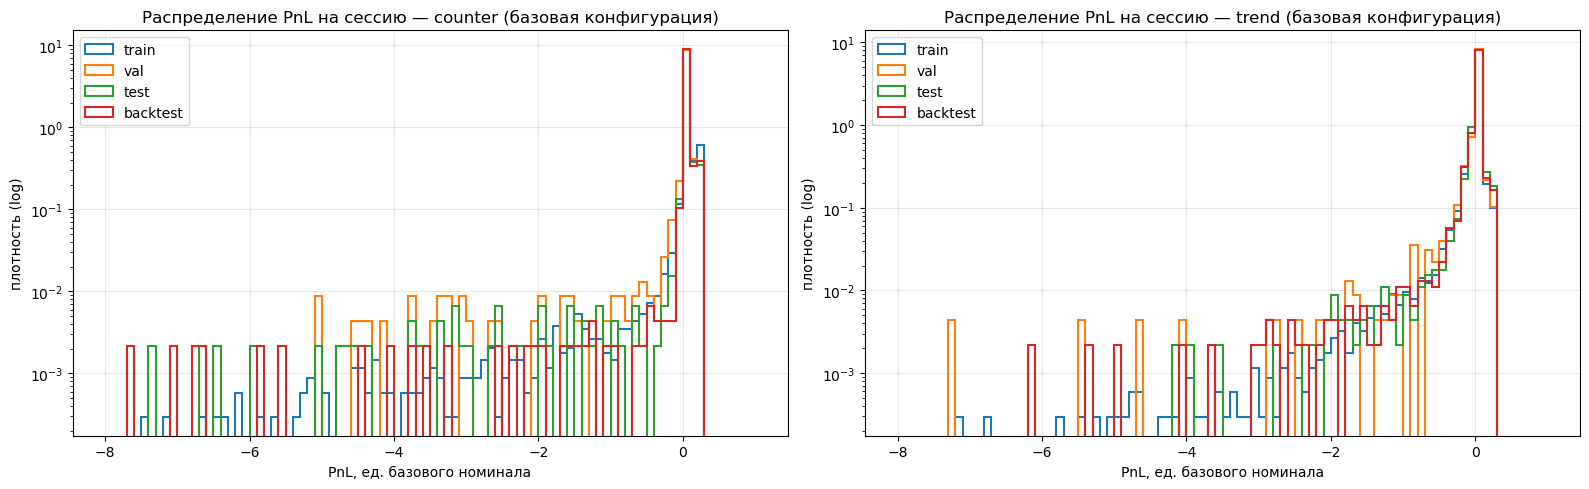

In [25]:
rows = []
for (side, s), res in base_res.items():
    dist = res['n_adds'].value_counts(normalize=True).sort_index() * 100
    row = {'side': side, 'split': s}
    row.update({f'{k} докупок, %': dist.get(k, 0.0) for k in range(BASE_CFG['max_adds'] + 1)})
    row['PnL если max_adds (mean)'] = res.loc[res['n_adds'] >= BASE_CFG['max_adds'], 'pnl'].mean()
    row['TP rate если max_adds, %'] = res.loc[res['n_adds'] >= BASE_CFG['max_adds'], 'tp'].mean() * 100
    rows.append(row)
print('Распределение числа докупок (базовая конфигурация)')
display(pd.DataFrame(rows).set_index(['side', 'split']).round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, side in zip(axes, ['counter', 'trend']):
    for s in SPLITS:
        pnl = base_res[(side, s)]['pnl'].values
        ax.hist(pnl, bins=np.linspace(-8, 1, 91), density=True, histtype='step', lw=1.5, color=SPLIT_COLORS[s], label=s)
    ax.set_yscale('log')
    ax.set_title(f'Распределение PnL на сессию — {side} (базовая конфигурация)')
    ax.set_xlabel('PnL, ед. базового номинала')
    ax.set_ylabel('плотность (log)')
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

**Перебор сетки.** 108 конфигураций × 4 сплита; результаты в `grid_df` (одна строка — конфигурация на сплите со всеми метриками `summarize_sim`).


In [26]:
GRID = [dict(side=side, step=step, mult=mult, tp=tp, max_adds=ma)
        for side in ['counter', 'trend'] for step in [0.01, 0.02, 0.03] for mult in [1.0, 2.0]
        for tp in [0.005, 0.01, 0.02] for ma in [3, 4, 5]]
rows = []
for cfg in GRID:
    for s in SPLITS:
        res = simulate_martingale(POST[s], **cfg)
        rows.append({**cfg, 'split': s, **summarize_sim(res, cfg['max_adds'], cfg['mult'])})
grid_df = pd.DataFrame(rows)
print(f'Конфигураций: {len(GRID)}, симуляций: {len(grid_df)}')

Конфигураций: 108, симуляций: 432


**Heatmap'ы.** Для `mult = 2`, `max_adds = 4`: по одной фигуре на сторону; столбцы — сплиты, строки — `step`, внутри — `tp`. Верхний ряд — `ret_on_capital` (%), нижний — `q1_pnl` (граница худшего 1% сессий, в единицах номинала).


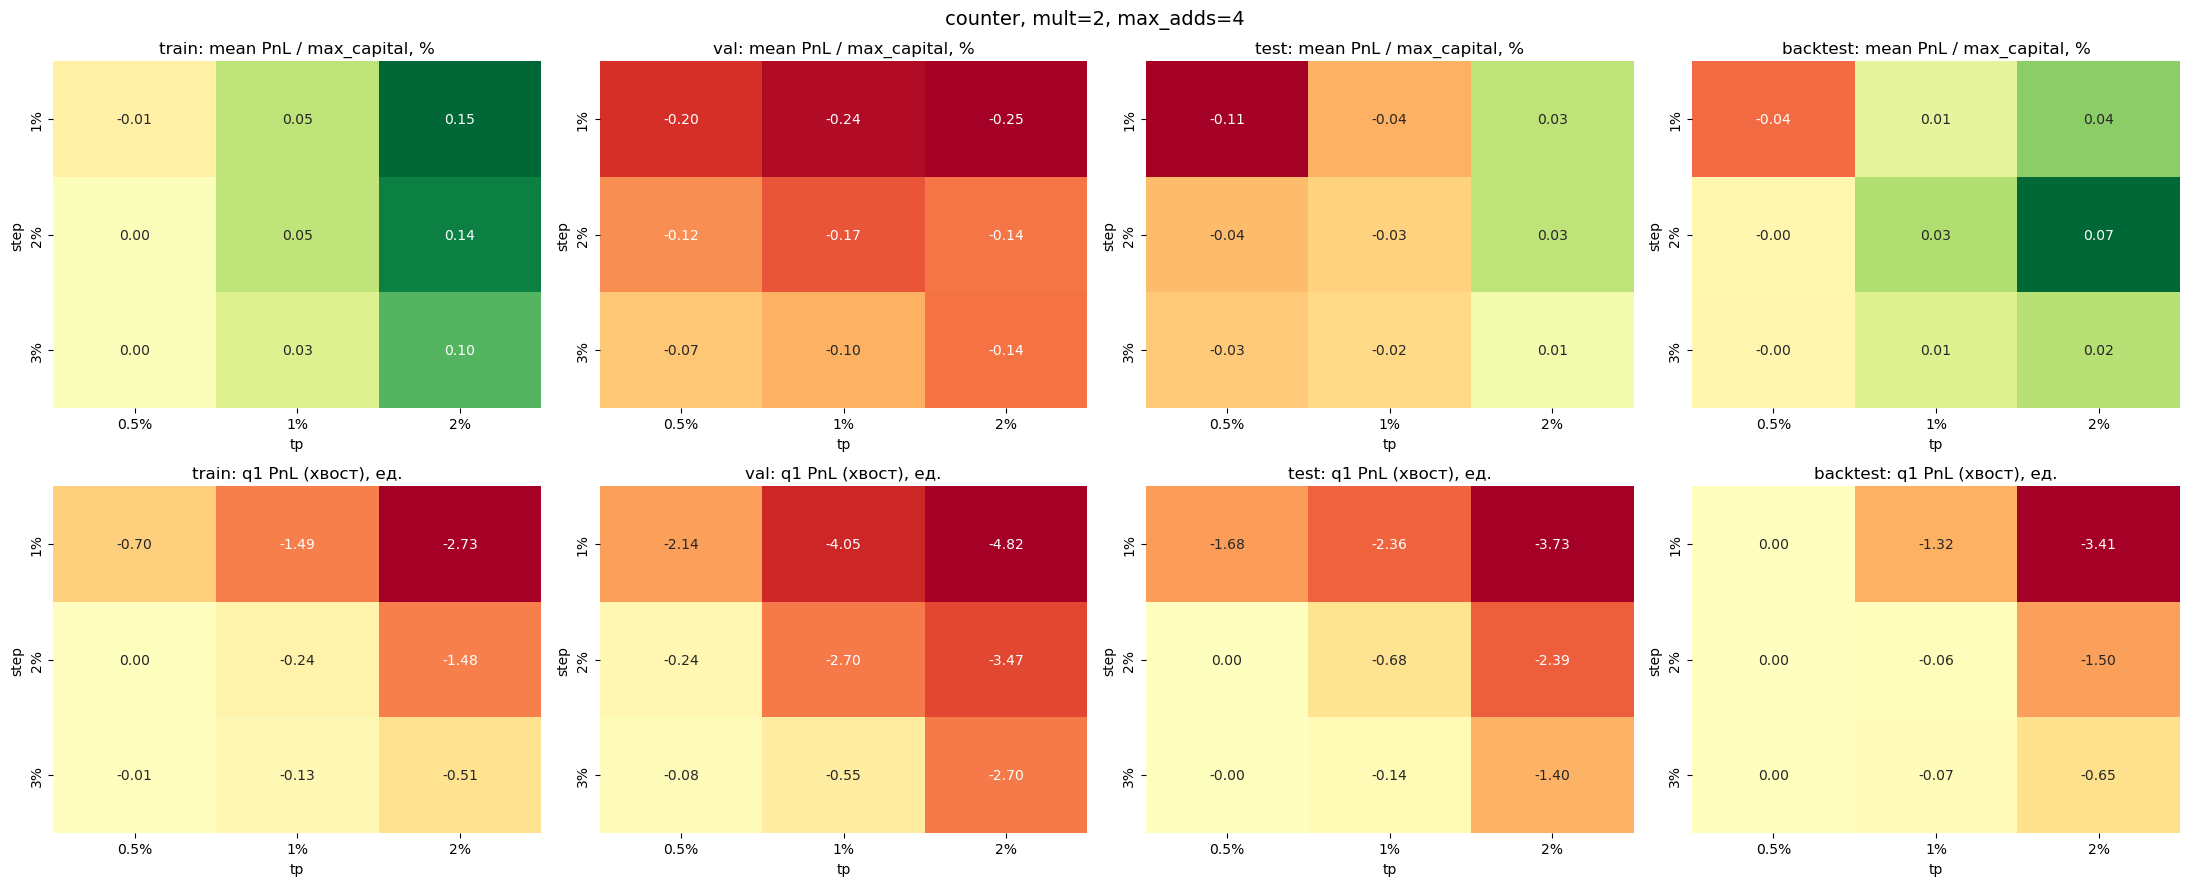

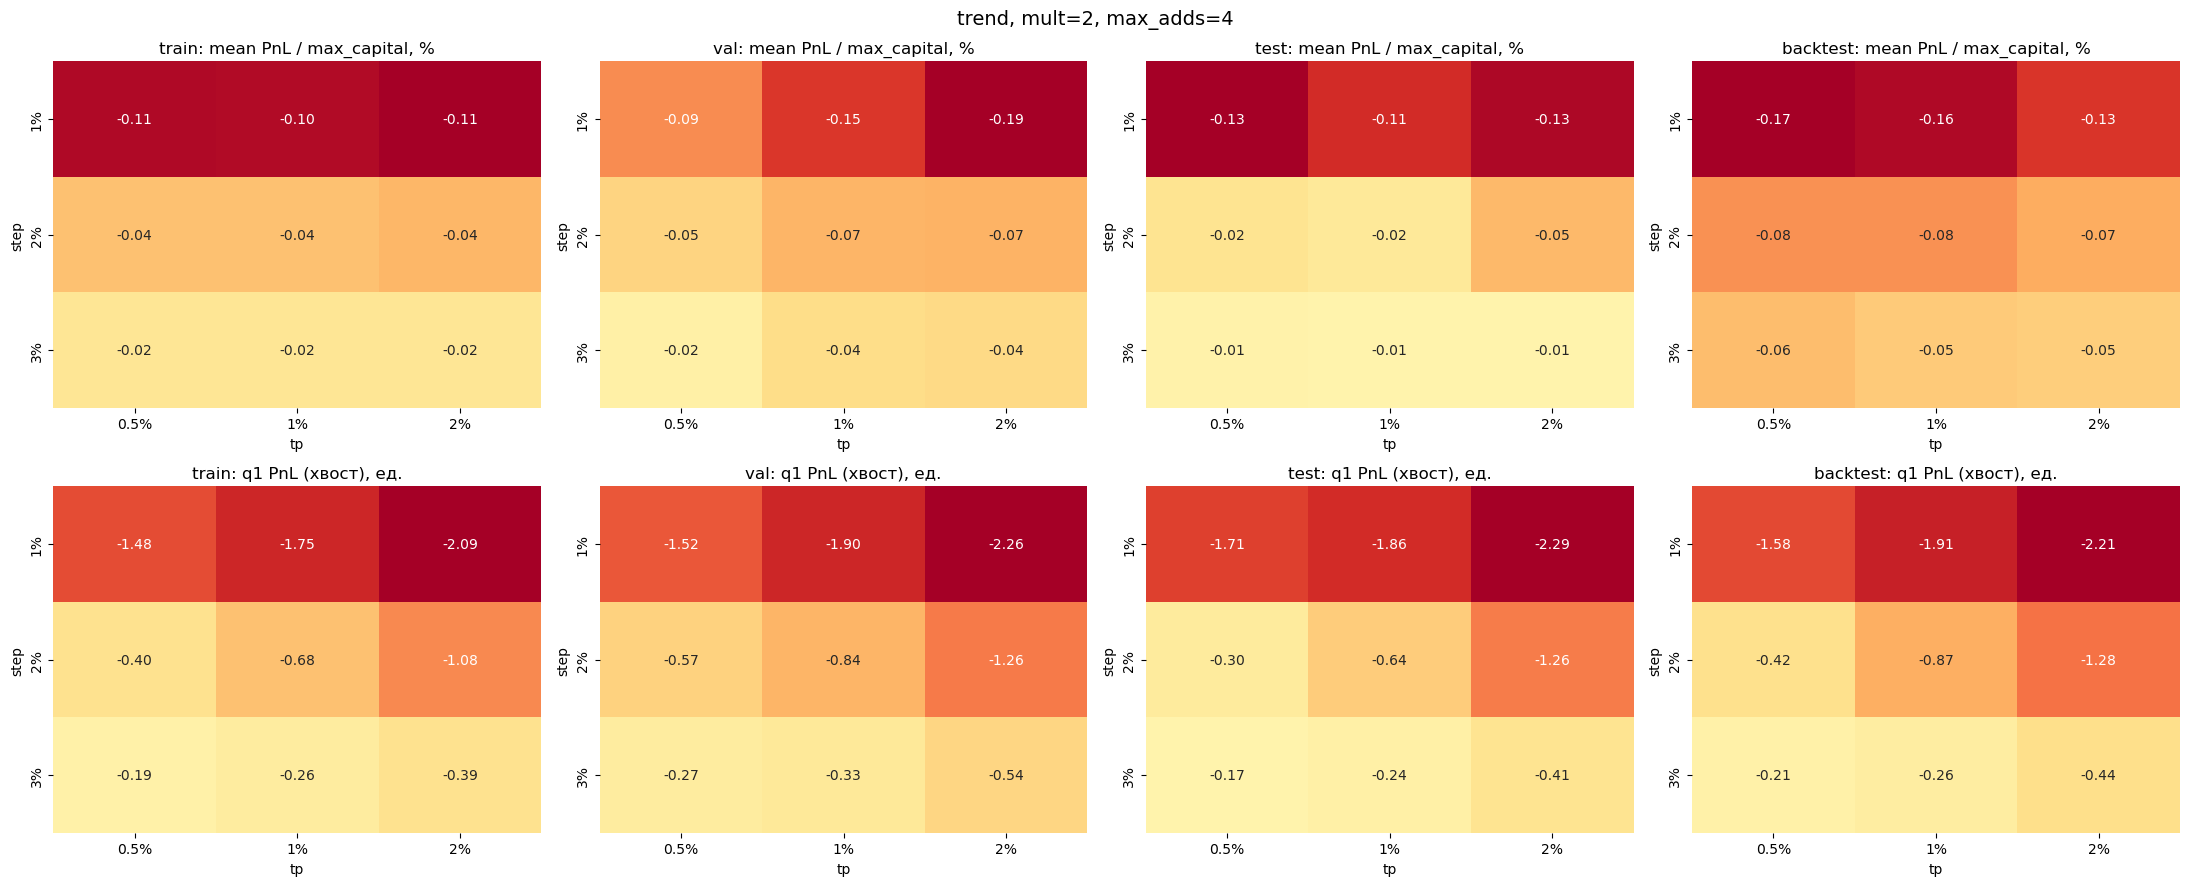

In [27]:
for side in ['counter', 'trend']:
    fig, axes = plt.subplots(2, 4, figsize=(22, 9))
    for j, s in enumerate(SPLITS):
        sub = grid_df[(grid_df['side'] == side) & (grid_df['mult'] == 2.0) & (grid_df['max_adds'] == 4) & (grid_df['split'] == s)]
        for i, (metric, ttl, cmap) in enumerate([('ret_on_capital_pct', 'mean PnL / max_capital, %', 'RdYlGn'),
                                                 ('q1_pnl', 'q1 PnL (хвост), ед.', 'RdYlGn')]):
            piv = sub.pivot(index='step', columns='tp', values=metric)
            piv.index = [f'{v*100:g}%' for v in piv.index]
            piv.columns = [f'{v*100:g}%' for v in piv.columns]
            sns.heatmap(piv, annot=True, fmt='.2f', cmap=cmap, center=0, ax=axes[i, j], cbar=False)
            axes[i, j].set_title(f'{s}: {ttl}')
            axes[i, j].set_xlabel('tp')
            axes[i, j].set_ylabel('step')
    fig.suptitle(f'{side}, mult=2, max_adds=4', fontsize=14)
    plt.tight_layout()
    plt.show()

**Таблицы по сетке.** Топ-10 конфигураций по train и их результат на остальных сплитах (доходность на капитал, profit factor, доля заполненных сеток); доля прибыльных конфигураций по сторонам и сплитам; корреляция Спирмена рангов конфигураций между train и другими сплитами; лучшая конфигурация каждого сплита с её значением на train; полная сетка.


In [28]:
def cfg_label(r):
    return f"{r['side']}|step={r['step']*100:g}%|x{r['mult']:g}|tp={r['tp']*100:g}%|adds={r['max_adds']}"


grid_df['cfg'] = grid_df.apply(cfg_label, axis=1)
wide = grid_df.pivot(index='cfg', columns='split', values='ret_on_capital_pct')[SPLITS]
wide_pf = grid_df.pivot(index='cfg', columns='split', values='profit_factor')[SPLITS]
wide_hit = grid_df.pivot(index='cfg', columns='split', values='max_adds_hit')[SPLITS]

print('Топ-10 конфигураций по train (mean PnL / max_capital, %) и их результат на остальных сплитах')
top = wide.sort_values('train', ascending=False).head(10)
display(pd.concat({'ret_on_capital_%': top, 'profit_factor': wide_pf.loc[top.index], 'max_adds_hit_%': wide_hit.loc[top.index]}, axis=1).round(3))

print('Доля конфигураций с положительным средним PnL по сплитам, %')
display((grid_df.groupby(['side', 'split'], observed=True)['mean_pnl'].apply(lambda x: np.mean(x > 0) * 100)).unstack()[SPLITS].round(1))

print('Spearman ρ рангов конфигураций (ret_on_capital) между train и остальными сплитами')
display(pd.Series({s: stats.spearmanr(wide['train'], wide[s])[0] for s in SPLITS if s != 'train'}).round(3).to_frame('rho').T)

print('Лучшая конфигурация каждого сплита (ret_on_capital, %) и её значение на train')
rows = []
for s in SPLITS:
    best = wide[s].idxmax()
    rows.append({'split': s, 'best cfg': best, 'ret_on_capital_% (свой сплит)': wide.loc[best, s],
                 'ret_on_capital_% (train)': wide.loc[best, 'train'],
                 'profit_factor (свой сплит)': wide_pf.loc[best, s], 'max_adds_hit_% (свой сплит)': wide_hit.loc[best, s]})
display(pd.DataFrame(rows).set_index('split').round(3))

print('Полная сетка: mean PnL / max_capital, % (все конфигурации × сплиты)')
display(wide.round(3))

Топ-10 конфигураций по train (mean PnL / max_capital, %) и их результат на остальных сплитах


ret_on_capital_%                        profit_factor                        max_adds_hit_%                         
split                                      train    val   test backtest         train    val   test backtest          train     val    test backtest
cfg                                                                                                                                                 
counter|step=3%|x1|tp=2%|adds=3            0.208 -0.185  0.087    0.099         1.565  0.739  1.190    1.213         10.058   9.071   8.258    8.187
counter|step=2%|x1|tp=2%|adds=3            0.206 -0.229  0.066    0.120         1.442  0.731  1.116    1.222         18.418  18.186  15.509   14.799
counter|step=2%|x1|tp=2%|adds=4            0.195 -0.201  0.061    0.099         1.518  0.725  1.128    1.217         11.842  11.131   9.836    9.282
counter|step=3%|x1|tp=2%|adds=4            0.194 -0.154  0.069    0.090         1.670  0.738  1.181    1.241          5.660   5.741   4.644    4.926
counter|step=2%|x1|tp=2%|adds=5            0.188 -0.190  0.052    0.094         1.600  0.706  1.126    1.245          8.063   7.625   6.835    6.217
counter|step=1%|x1|tp=2%|adds=5            0.179 -0.243  0.026    0.065         1.360  0.722  1.043    1.108         22.463  22.393  18.795   18.389
counter|step=1%|x1|tp=2%|adds=4            0.176 -0.267  0.021    0.059         1.309  0.722  1.031    1.087         27.898  28.089  25.016   23.446
counter|step=3%|x1|tp=2%|adds=5            0.175 -0.150  0.060    0.083         1.735  0.710  1.187    1.266          3.087   3.593   2.979    3.021
counter|step=1%|x1|tp=2%|adds=3            0.166 -0.301  0.033    0.090         1.248  0.718  1.042    1.119         35.552  35.627  32.267   31.480
counter|step=1%|x2|tp=2%|adds=3            0.161 -0.276 -0.002    0.053         1.341  0.679  0.997    1.094         34.354  34.400  31.369   29.969

Доля конфигураций с положительным средним PnL по сплитам, %


split,train,val,test,backtest
side,,,,
counter,81.5,0.0,29.6,68.5
trend,0.0,0.0,0.0,0.0


Spearman ρ рангов конфигураций (ret_on_capital) между train и остальными сплитами


,val,test,backtest
rho,0.052,0.907,0.987


Лучшая конфигурация каждого сплита (ret_on_capital, %) и её значение на train


,best cfg,ret_on_capital_% (свой сплит),ret_on_capital_% (train),profit_factor (свой сплит),max_adds_hit_% (свой сплит)
split,,,,,
train,counter|step=3%|x1|tp=2%|adds=3,0.208,0.208,1.565,10.058
val,trend|step=3%|x2|tp=0.5%|adds=5,-0.007,-0.008,0.561,0.263
test,counter|step=3%|x1|tp=2%|adds=3,0.087,0.208,1.190,8.258
backtest,counter|step=2%|x1|tp=2%|adds=3,0.120,0.206,1.222,14.799


Полная сетка: mean PnL / max_capital, % (все конфигурации × сплиты)


split,train,val,test,backtest
cfg,,,,
counter|step=1%|x1|tp=0.5%|adds=3,-0.062,-0.331,-0.168,-0.129
counter|step=1%|x1|tp=0.5%|adds=4,-0.048,-0.310,-0.140,-0.106
counter|step=1%|x1|tp=0.5%|adds=5,-0.033,-0.269,-0.124,-0.085
counter|step=1%|x1|tp=1%|adds=3,0.048,-0.346,-0.065,0.002
counter|step=1%|x1|tp=1%|adds=4,0.048,-0.318,-0.048,0.003
counter|step=1%|x1|tp=1%|adds=5,0.050,-0.293,-0.033,-0.009
counter|step=1%|x1|tp=2%|adds=3,0.166,-0.301,0.033,0.090
counter|step=1%|x1|tp=2%|adds=4,0.176,-0.267,0.021,0.059
counter|step=1%|x1|tp=2%|adds=5,0.179,-0.243,0.026,0.065


**Кластеризация во времени.** Для каждой минуты сигнала считается число сессий (разных тикеров) с этой же минутой; в таблице — число уникальных минут, максимум одновременных сессий, доли сессий с ≥ 5 и ≥ 10 одновременными и доля разворотов через 60 мин в кластерах против одиночных сигналов.


In [29]:
cnt = df.groupby(['split', 'datetime'], observed=True).size().rename('simultaneous')
df['simultaneous'] = df.set_index(['split', 'datetime']).index.map(cnt).values
rows = []
for s in SPLITS:
    sub = df[df['split'] == s]
    per_min = cnt.loc[s]
    rows.append({'split': s, 'сессий': len(sub), 'уникальных минут сигнала': len(per_min),
                 'макс. сессий в одну минуту': per_min.max(),
                 'доля сессий с ≥5 одновременными, %': np.mean(sub['simultaneous'] >= 5) * 100,
                 'доля сессий с ≥10 одновременными, %': np.mean(sub['simultaneous'] >= 10) * 100,
                 'разворот@60 при ≥5 одновр., %': np.mean(sub.loc[sub['simultaneous'] >= 5, 'r_60'] < 0) * 100,
                 'разворот@60 при одиночных, %': np.mean(sub.loc[sub['simultaneous'] == 1, 'r_60'] < 0) * 100})
print('Кластеризация сигналов во времени (одновременные сессии по разным тикерам => коррелированный риск мартингейла)')
display(pd.DataFrame(rows).set_index('split').round(1))

Кластеризация сигналов во времени (одновременные сессии по разным тикерам => коррелированный риск мартингейла)


,сессий,уникальных минут сигнала,макс. сессий в одну минуту,"доля сессий с ≥5 одновременными, %","доля сессий с ≥10 одновременными, %","разворот@60 при ≥5 одновр., %","разворот@60 при одиночных, %"
split,,,,,,,
train,34243,19045,294,41.9,37.2,65.9,58.9
val,2282,1842,45,15.5,12.5,58.2,57.1
test,4565,3986,160,8.6,7.3,71.8,63.1
backtest,4568,3576,393,18.7,18.2,86.8,59.0


## F. Выводы

Числа ниже — из прогона на полных сплитах (train 34 243 / val 2 282 / test 4 565 / backtest 4 568 сессий); порядок в скобках всегда train / val / test / backtest.

### Сколько сессий разворачиваются, сколько продолжают
- По знаку `r_h` цена чаще оказывается **по ту сторону `P0`** (откат), чем продолжает движение: доля разворотов через 60 мин — **62.1 / 57.2 / 63.8 / 64.4 %**. Доля почти не зависит от горизонта: уже через 3–5 минут она выходит на ~62–64 % (train) и дальше не меняется, т.е. «сторона» пост-окна определяется в первые минуты.
- С порогом шума `θ = 1%` через 60 мин: continuation **28.6 / 34.7 / 28.2 / 28.5 %**, flat **19.1 / 16.2 / 18.2 / 16.8 %**, reversal **52.3 / 49.2 / 53.6 / 54.6 %**.
- Медиана подписанной доходности через 60 мин отрицательна везде: `r_60` = **−1.22 / −0.93 / −1.33 / −1.43 %**. Среднее тоже отрицательно на train/test/backtest (≈ −0.65 %), но на val ≈ 0 — правый хвост продолжений там компенсирует откаты.
- Down-сигналы (дампы) откатывают чаще, чем up-сигналы (пампы): по знаку через 60 мин **68.3 % vs 55.6 %** на train, **70.9 % vs 58.9 %** на backtest; на test разница стирается (62.7 vs 64.6), а на val down-сигналы откатывают лишь в 53.8 % случаев.

### Насколько резко
- Типичное движение после сигнала — около половины сигнального: медиана `MAE/M` = **0.53 / 0.51 / 0.56 / 0.55**, медиана `MFE/M` = **0.46 / 0.46 / 0.41 / 0.40**. В процентах: MAE (макс. откат) медиана **3.24 / 3.24 / 3.46 / 3.55 %**, MFE (макс. продолжение) **2.83 / 2.92 / 2.50 / 2.55 %**.
- Хвосты асимметричны: продолжения тяжелее (train q95 MFE = 16.0 % против q95 MAE = 9.2 %). Именно этот хвост даёт катастрофические сессии для контртрендовых позиций (пример: TUTUSDT 2025-03-27, +123 % за час после сигнала).
- Откат на половину сигнала за 60 мин происходит в **53.5 / 51.4 / 55.7 / 56.1 %** сессий, полный откат к цене до сигнала — только в **13.7 / 16.7 / 16.7 / 16.8 %**. Продолжение ещё на величину сигнала (`≥1·M`) — в **24.5 / 25.5 / 20.6 / 21.7 %**.
- «Ретриггер» (в пост-окне есть 10-минутное движение ≥ 5 %, т.е. событие уровня сигнала) встречается в **~32–34 %** сессий во всех сплитах; из них по направлению сигнала **44 / 60 / 49 / 47 %**, остальное — резкие развороты. Так что «резкий разворот» (сравнимый с сигналом) — это ~13–18 % всех сессий, «резкое продолжение» — ~14–19 %.
- По скорости разворот заметно медленнее сигнала: медианная скорость до впадины ≈ 0.17–0.21 %/мин против 0.57–0.59 %/мин у сигнала (≈ 0.27–0.32×); быстрее сигнала откатывают только ~14–17 % сессий. Продолжение быстрее: ≈ 0.45–0.6× скорости сигнала, и 27–37 % сессий продолжают быстрее, чем шёл сигнал.
- Сила сигнала почти не меняет относительный откат (`MAE/M` ≈ 0.5–0.6 во всех корзинах `M`), но абсолютный откат растёт (медиана MAE 2.8 % при M 5–6 % → 8.8 % при M > 12 %), а доля разворотов по знаку растёт с 60 % до 76 % (train).

### Как долго
- Продолжение выдыхается быстро: медиана минуты максимума продолжения `t_peak` = **6 / 12 / 7 / 7**; уровень `0.5·M` продолжения достигается в медиане за **5 / 8 / 6 / 6** мин, `1·M` — за 10–15 мин.
- Откат развивается дольше: медиана `t_trough` = **22 / 21 / 23 / 19** мин, q75 ≈ 45 мин — минимум отката часто приходится на конец 60-минутного окна. Откат на `0.5·M` в медиане наступает через **9 / 12 / 10 / 11** мин, полный откат — через **29 / 27 / 25 / 24** мин.
- По кривым «ещё не достигли»: к 60-й минуте ~46 % сессий так и не откатили половину сигнала, ~85 % не откатили его полностью; после 30-й минуты новые экстремумы продолжения ставят лишь 23–28 % сессий.

### train против val / test / backtest
- Разный состав сигналов: доля up-сигналов **48.8 / 66.7 / 58.8 / 53.9 %**, поэтому агрегированные сравнения частично отражают именно микс направлений (см. таблицы по up/down).
- **val — выброс**: меньше разворотов (57 % vs 62 %), больше продолжений (`r_60 ≥ 1 %`: 34.7 % vs 28.6 %), ретриггеры чаще по сигналу (60 % vs 44 %), позже пик продолжения (12 vs 6 мин). 24 из 31 метрик значимо отличаются от train, ранги конфигураций мартингейла с train не коррелируют (ρ = 0.05).
- **test и backtest близки к train по направлению** (63.8 / 64.4 % vs 62.1 %), но откаты там глубже (MAE 3.46 / 3.55 % vs 3.24 %; полный откат 16.7 / 16.8 % vs 13.7 %; откат ≥ 5 %: 28.7 / 30.3 % vs 25.8 %), а продолжения слабее (MFE 2.50 / 2.55 % vs 2.83 %; `≥1·M` 20.6 / 21.7 % vs 24.5 %). При таких `n` значимы почти все отличия (21 и 27 метрик), но по величине это сдвиг на 0.2–0.4 п.п. MAE и 2–4 п.п. долей — режим в целом тот же, чуть более «возвратный».
- По направлениям: для up-сигналов все три поздних сплита откатывают глубже train (MAE 3.5–3.7 % vs 2.9 %, полный откат 19–21 % vs 12 %); для down-сигналов val/test откатывают заметно реже train (54 / 63 % vs 68 %), backtest — как train (71 %).

### Симуляция мартингейла
- Контртрендовый мартингейл (базовая конфигурация: шаг 2 %, ×2, TP 1 %, 4 докупки, издержки 0.065 % на сторону) закрывается по TP в **97.2 / 94.5 / 97.0 / 98.1 %** сессий, но средний PnL на сессию (в единицах базового номинала) = **+0.014 / −0.052 / −0.008 / +0.008**, profit factor **1.67 / 0.36 / 0.77 / 1.38**, доходность на максимальный капитал сетки **+0.046 / −0.169 / −0.027 / +0.026 %** за сессию. Весь результат определяют 4.5–7 % сессий, дошедших до максимума докупок (средний PnL там −0.05 … −1.1 ед., худшие сессии −32 … −72 ед. при капитале сетки 31).
- Трендовый мартингейл убыточен во всех сплитах и во всех 54 конфигурациях сетки.
- По сетке из 108 конфигураций: положительное среднее у контртрендовых конфигураций в **81.5 / 0 / 29.6 / 68.5 %** случаев. Лучшая на train (`counter | step 3 % | ×1 | TP 2 % | 3 докупки`): **+0.208 / −0.185 / +0.087 / +0.099 %** капитала за сессию. Ранжирование конфигураций переносится на test/backtest (Spearman 0.91 / 0.99), но не на val (0.05). Стабильно лучше работают более широкий TP (2 %) и сетка без удвоения (×1): удвоение не улучшает среднее, а только утяжеляет хвост (q1 PnL).
- Сигналы кластеризуются: на train 42 % сессий имеют ≥ 5 одновременных сессий по другим тикерам (до 294 тикеров в одну минуту, на backtest — до 393). В кластерах доля разворотов выше (train / test / backtest: 66–87 %, val: 58 %), но позиции по разным тикерам коррелированы, и реальный капитал под сетку — это `max_capital` × число одновременных сессий, а не одна сетка.

### Итог по применимости мартингейла
После 10-минутного движения ≥ 5 % цена чаще откатывает (≈ 62–64 % по знаку, ≈ 52–55 % с порогом 1 %), типичный откат — около половины сигнала за ~10 мин (половина) и ~25–30 мин (полный), а продолжение, когда оно случается, быстрее и с более тяжёлым хвостом. Статистический перевес в сторону отката есть, но он тонкий (медиана `r_60` ≈ −1.2 %, среднее ≈ −0.6 % и ≈ 0 на val) и режимозависимый. Контртрендовый мартингейл даёт высокий процент прибыльных сессий при околонулевом матожидании после издержек и с неустойчивым знаком по периодам (val и test — минус); ограничивающий фактор — хвост продолжений и одновременность сигналов, а не частота разворотов. Трендовый мартингейл не оправдан ни в одном сплите.

_Оговорки: PnL без плеча и ликвидаций; внутрисвечной порядок high/low неизвестен (взята консервативная схема: докупки раньше TP, TP не проверяется в свече с докупкой); результат чувствителен к издержкам (при TP 1 % они съедают ~13 % прибыли сделки)._


## G. Литература и ссылки

**Статистика**
- Доверительные интервалы для доли, интервал Уилсона: [Binomial proportion confidence interval](https://en.wikipedia.org/wiki/Binomial_proportion_confidence_interval), [Доверительный интервал](https://ru.wikipedia.org/wiki/Доверительный_интервал); Wilson E. B. (1927) «Probable inference, the law of succession, and statistical inference», JASA 22(158); Brown L. D., Cai T. T., DasGupta A. (2001) «Interval Estimation for a Binomial Proportion», Statistical Science 16(2). Реализация: [`statsmodels.stats.proportion.proportion_confint(method='wilson')`](https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportion_confint.html).
- Проверка гипотез и p-значение: [Проверка статистических гипотез](https://ru.wikipedia.org/wiki/Проверка_статистических_гипотез), [P-значение](https://ru.wikipedia.org/wiki/P-значение), [Z-test](https://en.wikipedia.org/wiki/Z-test), [`statsmodels.stats.proportion.proportions_ztest`](https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportions_ztest.html), [Kolmogorov–Smirnov test](https://en.wikipedia.org/wiki/Kolmogorov%E2%80%93Smirnov_test), [`scipy.stats.ks_2samp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ks_2samp.html).
- Множественные сравнения, величина эффекта, смешение: [Multiple comparisons problem](https://en.wikipedia.org/wiki/Multiple_comparisons_problem), [Bonferroni correction](https://en.wikipedia.org/wiki/Bonferroni_correction), [Effect size](https://en.wikipedia.org/wiki/Effect_size), [Парадокс Симпсона](https://ru.wikipedia.org/wiki/Парадокс_Симпсона), [Selection bias](https://en.wikipedia.org/wiki/Selection_bias).
- Описательная статистика: [Квантиль](https://ru.wikipedia.org/wiki/Квантиль), [Медиана](https://ru.wikipedia.org/wiki/Медиана_%28статистика%29), [Interquartile range](https://en.wikipedia.org/wiki/Interquartile_range), [Empirical distribution function](https://en.wikipedia.org/wiki/Empirical_distribution_function), [Heavy-tailed distribution](https://en.wikipedia.org/wiki/Heavy-tailed_distribution), [Spearman's rank correlation coefficient](https://en.wikipedia.org/wiki/Spearman%27s_rank_correlation_coefficient), [`scipy.stats.spearmanr`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html).
- Время до события: [Survival analysis](https://en.wikipedia.org/wiki/Survival_analysis), [Kaplan–Meier estimator](https://en.wikipedia.org/wiki/Kaplan%E2%80%93Meier_estimator).

**Финансы и трейдинг**
- MFE / MAE: Sweeney J. (1996) «Maximum Adverse Excursion: Analyzing Price Fluctuations for Trading Management», Wiley.
- Краткосрочный возврат к среднему и импульс: Jegadeesh N. (1990) «Evidence of Predictable Behavior of Security Returns», Journal of Finance 45(3); Lehmann B. N. (1990) «Fads, Martingales, and Market Efficiency», Quarterly Journal of Economics 105(1); [Mean reversion (finance)](https://en.wikipedia.org/wiki/Mean_reversion_%28finance%29), [Momentum (finance)](https://en.wikipedia.org/wiki/Momentum_%28finance%29).
- Мартингейл и риск разорения: [Martingale (betting system)](https://en.wikipedia.org/wiki/Martingale_%28betting_system%29), [Risk of ruin](https://en.wikipedia.org/wiki/Risk_of_ruin), [Gambler's ruin](https://en.wikipedia.org/wiki/Gambler%27s_ruin), [Value at risk](https://en.wikipedia.org/wiki/Value_at_risk), [Slippage (finance)](https://en.wikipedia.org/wiki/Slippage_%28finance%29).
- Переобучение бэктестов и проверка вне выборки: Bailey D. H., Borwein J., López de Prado M., Zhu Q. J. (2014) «Pseudo-Mathematics and Financial Charlatanism: The Effects of Backtest Overfitting on Out-of-Sample Performance», Notices of the AMS 61(5); López de Prado M. (2018) «Advances in Financial Machine Learning», Wiley (главы о бэктестинге); [Backtesting](https://en.wikipedia.org/wiki/Backtesting), [Переобучение](https://ru.wikipedia.org/wiki/Переобучение).
- Свечи OHLC: [Open-high-low-close chart](https://en.wikipedia.org/wiki/Open-high-low-close_chart).

**Инструменты**
- [`numpy.where`](https://numpy.org/doc/stable/reference/generated/numpy.where.html), [`numpy.argmax`](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html), [`numpy.quantile`](https://numpy.org/doc/stable/reference/generated/numpy.quantile.html)
- [`pandas.cut`](https://pandas.pydata.org/docs/reference/api/pandas.cut.html), [`DataFrame.pivot`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.pivot.html), [groupby](https://pandas.pydata.org/docs/user_guide/groupby.html)
- [`matplotlib.pyplot.hexbin`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hexbin.html), [`matplotlib.pyplot.hist`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html), [`seaborn.heatmap`](https://seaborn.pydata.org/generated/seaborn.heatmap.html)
- Код детектора сигналов: `signal_detection/signal_detection.py` (параметры — `signal_detection/config.py`); параметры издержек: `rl-trading-binance/config.py` (`MarketConfig`).
